In [5]:
import warnings

warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import matplotlib as mat
import os
import seaborn as sns
import numpy as np
import matplotlib.ticker as mticker
import ast
import json
from matplotlib import colors

from PIL import ImageColor
import glob
import matplotlib.ticker as ticker
import pathlib
import scipy.stats as st
from scipy.optimize import curve_fit
from scipy.stats import poisson, norm
from brokenaxes import brokenaxes

from sklearn import preprocessing
import re

import scipy.stats as st

from fitter import Fitter

# %#config IPCompleter.greedy=True
# %#matplotlib notebook
# %#matplotlib inline
plt.rcParams["figure.figsize"] = [4, 4]

POINT_PLOT_DODGE = 0.15
sns.set(font_scale=1.25, style="ticks")
FIGSIZE = [6, 6]
plt.style.use("tableau-colorblind10")
# PALETTE = sns.cubehelix_palette(as_cmap\=False, n_colors=3, reverse=False, light=0.7)
print("hot stuff")

import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 16,          # base
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "legend.title_fontsize": 15,
    "lines.markersize": 8,
    "lines.linewidth": 2.2,
})
plt.rcParams['figure.constrained_layout.use'] = False

hot stuff


In [6]:
from cycler import cycler
okabe_ito = [
    "#000000",  # black
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#009E73",  # bluish green
    "#F0E442",  # yellow
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
]

# ax1.set_prop_cycle(cycler(color=okabe_ito))

In [7]:
import numpy as np
import re

_interval_re = re.compile(r"^\s*(\d+\.?\d*)\s*-\s*(\d+\.?\d*)\s*$")

def _bins_to_piecewise_cdf(bin_columns, bin_counts, offset_us=0.0):
    """
    Build x/y points for a CDF that increases *across* each bin width.
    Returns arrays x, y where y is in [0, 1].
    """
    starts, ends, counts = [], [], []
    for col, c in zip(bin_columns, bin_counts):
        m = _interval_re.match(str(col))
        if not m:
            continue
        s, e = map(float, m.groups())
        starts.append(s - offset_us)
        ends.append(e - offset_us)
        counts.append(float(c))

    starts = np.array(starts, dtype=float)
    ends   = np.array(ends, dtype=float)
    counts = np.array(counts, dtype=float)

    # sort by start
    order = np.argsort(starts)
    starts, ends, counts = starts[order], ends[order], counts[order]

    total = counts.sum()
    if total <= 0 or len(starts) == 0:
        return np.array([0.0]), np.array([0.0])

    x = [starts[0]]
    y = [0.0]
    acc = 0.0

    for s, e, c in zip(starts, ends, counts):
        # if gap, keep CDF flat until next bin
        if x[-1] < s:
            x.append(s)
            y.append(acc / total)

        # linearly increase through the bin to its end
        x.append(e)
        acc += c
        y.append(acc / total)

    return np.array(x), np.array(y)


def percentile_from_cdf(x, y, p):
    """p in [0,1]. x must be increasing, y non-decreasing."""
    return float(np.interp(p, y, x))


In [8]:
def collect_csv_files(root_dir):
    """
    Traverse the directory structure to collect all CSV file paths.

    Args:
    root_dir (str): The root directory where experiments are stored.

    Returns:
    csv_files (list): List of file paths to all CSV files found.
    """
    csv_files = []

    # Walk through all folders and subfolders
    for dirpath, _, filenames in os.walk(root_dir):
        for filename in filenames:
            if filename.endswith(".csv"):
                csv_files.append(os.path.join(dirpath, filename))

    return csv_files


def clean_column_names(columns, maximum):
    new_columns = []
    interval_pattern = re.compile(
        r"(\d+\.?\d*)[^\d]+([^\s]+)us"
    )  # Pattern to match intervals

    for col in columns:
        if isinstance(col, str):  # Ensure col is a string before processing
            match = interval_pattern.search(col)
            if match:
                start, end = match.groups()
                if end == "x":
                    end = maximum
                new_columns.append(f"{start}-{end}")  # Example: '0-20'
            else:
                new_columns.append(col)

    return new_columns


def parse_and_merge_csv(csv_files):
    """
    Parse all CSV files and merge them into a single DataFrame,
    handling different column structures by filling NaN for missing columns.

    Args:
    csv_files (list): List of file paths to the CSV files.

    Returns:
    merged_df (pd.DataFrame): Merged DataFrame with all data from CSV files.
    """
    dataframes = []

    for file in csv_files:
        # Extract experiment details from the directory structure
        path_parts = file.split(os.sep)
        experiment = path_parts[
            -4
        ]  # Assuming experiment/level/packet_size/output_file.csv
        level = path_parts[-3]
        packet_size = path_parts[-2]

        # Read the CSV file into a DataFrame
        df = pd.read_csv(file)

        if df.columns is None or len(df.columns) == 0:
            print(f"Warning: {file} has no column names or columns are empty.")

        # df.columns = clean_column_names(df.columns)

        # Add metadata columns to identify the experiment, level, and packet size
        df["Experiment"] = (
            experiment if "tc" not in experiment else int(experiment.strip("tc"))
        )
        df["Level"] = int(level)
        df["Packet Size"] = int(packet_size)
        df["IPv4 :Raw priority"] = df["IPv4 :Raw priority"].apply(
            lambda x: int(x[2], 16)
        )

        # Append the DataFrame to the list
        dataframes.append(df)

    # Merge all DataFrames, handling different columns by filling missing ones with NaN
    merged_df = pd.concat(dataframes, ignore_index=True, sort=False)

    return merged_df


def group_and_clean(df, maximums, groups):
    grouped_df = df.groupby(groups, as_index=False)

    f = dict()

    for index, group in grouped_df:
        # f[index] = clean_column_names(group.dropna(axis=1, how='all'))
        g = group.dropna(axis=1, how="all")
        # print(group['Cut-Through Max Latency (ns)'].max())
        # g.columns = clean_column_names(g, group['Cut-Through Max Latency (ns)'].max()/10**3)

        if index in maximums:
            max_applied = maximums[index]
        else:
            max_applied = (0, maximums[index][1], maximums[index][2])
        g.columns = clean_column_names(g, maximums[index])
        # print(g.columns)
        f[index] = g

    return f


def get_only_bins_per_flowgroup(df, column, flow_group="", negative_match=""):
    interval_pattern = re.compile(r".*-.*")  # Pattern for intervals
    interval_columns = [
        col
        for col in df.columns
        if interval_pattern.search(col) and "Latency" not in col
    ]

    if flow_group == "":
        df = df[df[column] != negative_match]
    else:
        df = df[df[column] == flow_group]
    return df[interval_columns]

def get_median_tail(
    ranges, cumsum
):  # Given cumulative sum data and corresponding intervals
    # Use lambda to split the string and convert to tuple
    destination = [lambda rambda: tuple(map(float, r.split("-"))) for r in ranges]

    # Now execute the lambdas to get the final destination list
    intervals = [rambda(ranges) for rambda in destination]

    # Total count
    total_count = cumsum[-1]

    # Median: find the value where the cumulative sum reaches 50% of the total count
    median_target = total_count * 0.5
    percentile_99_target = total_count * 0.99

    # Find the interval for median and 99th percentile
    median_interval = None
    percentile_99_interval = None

    for i in range(1, len(cumsum)):
        if cumsum[i] >= median_target and median_interval is None:
            median_interval = intervals[i]
        if cumsum[i] >= percentile_99_target and percentile_99_target is None:
            percentile_99_target = intervals[i]

    return median_interval, percentile_99_target

def draw_ecdf_plot(ax, lims, data, flowgroup, label, linestyle):
    # data: DataFrame of *bin columns only* (as in your current call)
    counts = data.sum(axis=0).to_numpy(dtype=float)

    # Build proper CDF across unequal bin widths
    x, y = _bins_to_piecewise_cdf(
        bin_columns=data.columns.values,
        bin_counts=counts,
        offset_us=23.957,   # keep your existing offset
    )

    # Percentiles now make sense even with unequal bins
    p50 = percentile_from_cdf(x, y, 0.50)
    p99 = percentile_from_cdf(x, y, 0.99)
    print(f"{label}", "50%=", p50, "99%=", p99)

    # Plot (line; not step-at-end)
    ax.plot(x, y * 100, label=label, )
    ax.step(x, y * 100, where="post", alpha=0.2, color='gray')
    
    # keep your formatting
    ax.xaxis.set_major_locator(ticker.AutoLocator())
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_major_locator(ticker.AutoLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

    ax.set_xlim(lims)
    ax.set_ylim([0, 100])

    fig.subplots_adjust(hspace=0.8, wspace=0.4)
    sns.despine()

def draw_ecdf_plots(
    axes,
    data,
    flowgroup,
    lims,
    save,
    directory,
    filename,
    legend,
    linestyle="solid",
    colors=plt.rcParams["axes.prop_cycle"].by_key()["color"],
):
    color_iterator = 0
    extended = False

    for i in range(0, len(data)):
        grp_index = list(data.keys())[i]

        df = data[grp_index]
        df = get_only_bins_per_flowgroup(
            df,
            flowgroup["column"],
            flowgroup["name"],
            flowgroup["negative_match"] if "negative_match" in flowgroup else "",
        )
                        
        print(f"{grp_index}")

        x = df.sum().cumsum()
        max_val = x[-1]

        ax = None

        line = None
        if type(axes) == np.ndarray:
            if grp_index[-1] == 512:
                draw_ecdf_plot(axes[0], lims, df, flowgroup, grp_index[0], linestyle)
            if grp_index[-1] == 1518:
                draw_ecdf_plot(axes[1], lims, df, flowgroup, grp_index[0], linestyle)
        else:
            draw_ecdf_plot(axes, lims, df, flowgroup, grp_index[0], linestyle)

    if legend:
        if isinstance(axes, np.ndarray):
            handles, labels = axes[0].get_legend_handles_labels()
        else:
            handles, labels = axes.get_legend_handles_labels()

        if handles:  # avoid empty legend
            fig.legend(
                handles,
                labels,
                loc="upper right",
                # ncol=len(labels),
                frameon=False,
            )
    # set locators
    try:
        for i in axes:
            i.xaxis.set_major_locator(ticker.AutoLocator())
            i.xaxis.set_minor_locator(ticker.AutoMinorLocator())
            i.yaxis.set_major_locator(ticker.AutoLocator())
            i.yaxis.set_minor_locator(ticker.AutoMinorLocator())
            i.set(xlabel="Latency (μs)", ylabel="Binned-ECDF (%)")

            i.set_xlim(lims)
            i.set_ylim([0, 100])
    except TypeError:
        axes.xaxis.set_major_locator(ticker.AutoLocator())
        axes.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        axes.yaxis.set_major_locator(ticker.AutoLocator())
        axes.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        axes.set(xlabel="Latency (μs)", ylabel="Binned-ECDF (%)")

        axes.set_xlim(lims)
        axes.set_ylim([0, 100])

    # ax1.legend(loc="upper left", bbox_to_anchor=(1, 0.9), title="Level")
    fig.subplots_adjust(hspace=0.8, wspace=0.4)

    # ax1[0].set_title("Background Traffic:\nPacket Size 512 Byte")
    # ax1[1].set_title("Background Traffic:\nPacket Size 1518 Byte")

    sns.despine()

    if save:
        if not os.path.exists(directory):
            os.makedirs(directory)
        fig.savefig(directory + filename, bbox_inches="tight")

Text(0.5, 1.0, 'Loss for High Priority Traffic\nNo Backpressure and Hardware Scheduler')

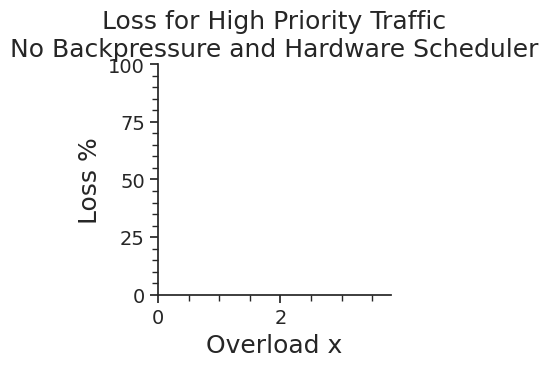

In [9]:
fig, ax1 = plt.subplots(1,1, figsize=(3,3))


ax1.set_xticks([0.8, 1, 1.2, 1.5, 1.92, 2, 3, 3.8])

ax1.set_ylabel('Loss %')
ax1.set_xlabel('Overload x')

ax1.xaxis.set_major_locator(ticker.AutoLocator())
ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())

ax1.yaxis.set_major_locator(ticker.AutoLocator())
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())

ax1.set_ylim([-0.25, 100])

sns.despine()
ax1.set_title('Loss for High Priority Traffic\nNo Backpressure and Hardware Scheduler')

# fig.savefig('./motivation_loss.pdf', bbox_inches="tight")

In [48]:
base_dir = "/home/rubinhus/Documents/phd/thesis/backpressure/data/submission/ninstances/"
pattern = "**/*Latency_Bins cross page.csv"

all_dfs = []

csv_files = glob.glob(os.path.join(base_dir, pattern), recursive=True)

for path in csv_files:
   
    # Split folder name into components safely
    folder = path.split("/")
    # Some directories may not follow exact pattern: guard length
    
    # parts = folder
    # print(folder)
    try:
        #ninstances = parts[-1] if len(parts) > 1 else None
        #ntc = parts[-2] if len(parts) > 2 else None
        # overload = float(parts[-4].strip("_"))
        # print(overload)
        overload =  float(folder[-4].split('_')[0])
        repeat = int(folder[-4].split('_')[1].strip('x'))
        instances = int(folder[-5].split('_')[0].strip('instances'))
        mode = folder[-5].split('_')[1]
        framesize = int(folder[-2])
        nflows = int(folder[-3])*instances
                          
        df = pd.read_csv(path)
        #df["Instance"] = int(ninstances.strip('instance'))
        #df["TC"] = int(ntc.strip('ntc'))
                          
        df['Overload'] = overload
        df['Instance'] = instances
        df['Mode'] = mode
        df['Framesize'] = framesize
        df['Repeat'] = repeat
        df['N Flows'] = nflows

        all_dfs.append(df)
    except Exception as e:
        print(f"Failed to parse {folder_name}: {e}")

# Combine all datasets
combined_df = pd.concat(all_dfs, ignore_index=True)

# Optional: sort or save
# combined_df = combined_df.sort_values(by="source")
# combined_df.to_csv("/home/rubinhus/combined_aggregateresults.csv", index=False)

print(f"Loaded {len(combined_df)} rows from {len(all_dfs)} files")

Loaded 7140 rows from 890 files


In [49]:
set(combined_df['Mode'])

{'aggbp', 'freerun', 'freerunswscheduler', 'pab', 'prioprop'}

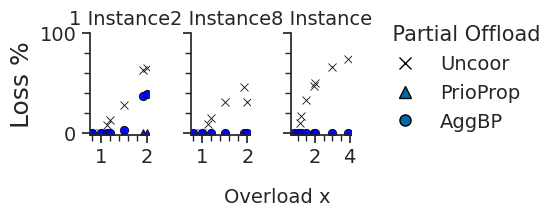

In [321]:
MODES = ["freerun", "prioprop", "aggbp"]
PRIOS = ["0x0"]  # you skip 0x1 anyway
INSTANCES = [1, 2, 8]

MARKERS = {"prioprop": "^", "aggbp": "o", "freerun": "x", "pab": "v"}
mode_display = {"aggbp": "AggBP", "prioprop": "PrioProp", "freerun": "Uncoor", "pab": "PAB"}
MODE_OFFSETS = {"aggbp": -0.04, "prioprop": 0.00, "freerun": 0.04}
PRIO_STYLE = {
    "0x0": dict(color="blue", linestyle="none"),
    "0x1": dict(color="orange", linestyle="--"),
}

fig, axes = plt.subplots(1, len(INSTANCES), figsize=(6, 3), sharey=True)
df = combined_df

def ci95(series: pd.Series) -> float:
    x = series.to_numpy(dtype=float)
    n = x.size
    if n <= 1:
        return 0.0
    se = np.std(x, ddof=1) / np.sqrt(n)
    return 1.96 * se  # approx 95% CI


for i, inst in enumerate(INSTANCES):
    ax = axes[i]
    p_df = df.query("Instance == @inst")

    for mode in MODES:
        for prio in PRIOS:
            m_df = p_df.query(
                "Mode == @mode and `IPv4 :Raw priority` == @prio"
            )

            if m_df.empty:
                continue

            g = (
                m_df.groupby("Overload")["Loss %"]
                .agg(mean="mean", ci=ci95)
                .reset_index()
                .sort_values("Overload")
            )

            style = PRIO_STYLE[prio]

            ax.errorbar(
                g["Overload"],
                g["mean"],
                yerr=g["ci"],
                fmt=MARKERS[mode],
                markersize=6,
                # capsize=2.5,
                elinewidth=1.0,
                markeredgecolor="black",
                markeredgewidth=0.6,
                linestyle=style["linestyle"],
                color=style["color"],
                # fillstyle=style["fillstyle"],
                alpha=0.95,
            )

            ax.plot(
                g["Overload"],
                g["mean"],
                linewidth=0.9,
                linestyle=style["linestyle"],
                color=style["color"],
                alpha=0.6,
            )    

            ax.set_ylim(-2, 100)

        ax.xaxis.set_major_locator(ticker.AutoLocator())
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_major_locator(ticker.AutoLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

        if i == 0:
            ax.set_ylabel("Loss %")

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        
mode_handles = [
    Line2D([0], [0], marker=MARKERS[m], linestyle="none",
           markeredgecolor="black", label=mode_display[m])
    for m in MODES
]

prio_handles = [
    Line2D([0], [0],
           color=PRIO_STYLE[p]["color"],
           linestyle=PRIO_STYLE[p]["linestyle"],
           marker="o",
           # fillstyle=PRIO_STYLE[p]["fillstyle"],
           label=f"High Prio" if p == "0x0" else "Low Prio")
    for p in PRIOS
]

ax_mode = axes[-1].legend(
    handles=mode_handles,
    title="    Partial Offload",
    loc="upper left",
    bbox_to_anchor=(0.95, 1.25),
    frameon=False,
    fontsize=14
)

fig.supxlabel("Overload x",y=0.15, fontsize=14)

n = 0
for ax in axes:
    ax.set_xlabel("")
    INSTANCES[n]

    ax.set_title(f"{INSTANCES[n]} Instance", fontsize=14)
    n+=1
    
(ax1,ax2,ax3) = axes

fig.tight_layout()
plt.show()

# fig.savefig(    "/home/rubinhus/Documents/phd/thesis/backpressure/plots/loss_motivation_instance_partial_offload.pdf",     bbox_inches="tight",)

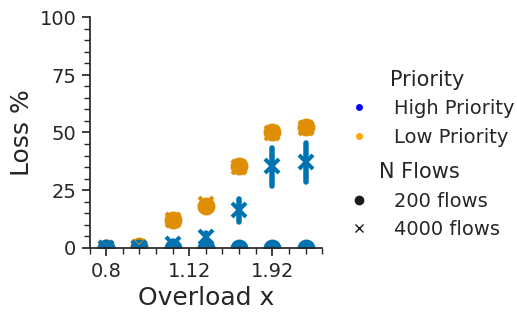

<Figure size 400x400 with 0 Axes>

In [322]:
fig, ax1 = plt.subplots(1,1, figsize=(3,3))

t_df = combined_df.copy()
# t_df = t_df[t_df['IPv4 :Raw priority'] == '0x0']

prio_palette = {
    '0x0': sns.color_palette('colorblind')[0],  # blue → High
    '0x1': sns.color_palette('colorblind')[1],  # orange → Low
}

flow_markers = {
    200: 'o',
    4000: 'x'
}


# --- filter ---
t_df = t_df[t_df["Repeat"] == 5]
t_df = t_df[t_df["Instance"] == 1]

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)


sns.pointplot(
    data=t_df[t_df['N Flows'] == 200],
    x='Overload',
    y='Loss %',
    hue='IPv4 :Raw priority',
    palette=prio_palette,
    markers=flow_markers[200],
    linestyles='none',
    ax=ax1,
    legend=False
)

sns.pointplot(
    data=t_df[t_df['N Flows'] == 4000],
    x='Overload',
    y='Loss %',
    hue='IPv4 :Raw priority',
    palette=prio_palette,
    markers=flow_markers[4000],
    linestyles='none',
    ax=ax1,
    legend=False
)

ax1.set_xticks([0.8, 1, 1.2, 1.5, 1.92, 2, 3, 3.8])

ax1.set_ylabel('Loss %')
ax1.set_xlabel('Overload x')

ax1.xaxis.set_major_locator(ticker.AutoLocator())
ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())

ax1.yaxis.set_major_locator(ticker.AutoLocator())
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
prio_palette = {'0x0': 'blue', '0x1': 'orange'}  # your example
flow_markers = {
    200: 'o',
    4000: 'x'
}

# ---- custom legend ----
prio_handles = [
    Line2D([0], [0],
           marker='o', linestyle='None',
           color='w', markerfacecolor=color,
           markersize=6, label=f'High Priority' if prio != '0x1' else 'Low Priority'
          
          )
    for prio, color in prio_palette.items()
]

flow_handles = [
    Line2D([0], [0], marker=marker, color='k',
           linestyle='None', markersize=6, label=f'{flows} flows')
    for flows, marker in flow_markers.items()
]

legend1 = ax1.legend(handles=prio_handles, title='Priority',
                     loc='upper left', frameon=False, bbox_to_anchor=(1, 0.85),)
ax1.add_artist(legend1)

ax1.legend(handles=flow_handles, title='N Flows',
           loc='upper left', frameon=False, bbox_to_anchor=(1, 0.45),)

ax1.set_ylim([-0.25, 100])

plt.tight_layout()
plt.show()
sns.despine()
# fig.savefig('/home/rubinhus/Documents/phd/thesis/backpressure/plots/single_instance_loss_n_flows.pdf', bbox_inches="tight")

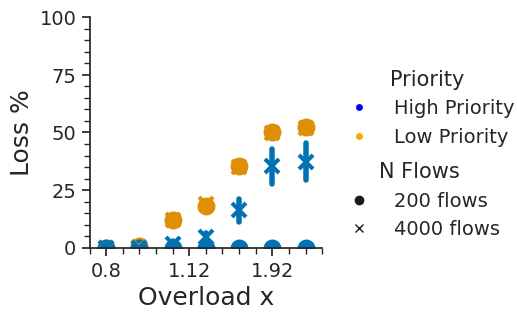

<Figure size 400x400 with 0 Axes>

In [256]:
fig, ax1 = plt.subplots(1,1, figsize=(3,3))

t_df = combined_df.copy()
# t_df = t_df[t_df['IPv4 :Raw priority'] == '0x0']

prio_palette = {
    '0x0': sns.color_palette('colorblind')[0],  # blue → High
    '0x1': sns.color_palette('colorblind')[1],  # orange → Low
}

flow_markers = {
    200: 'o',
    4000: 'x'
}


# --- filter ---
t_df = t_df[t_df["Repeat"] == 5]
t_df = t_df[t_df["Instance"] == 1]

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)


sns.pointplot(
    data=t_df[t_df['N Flows'] == 200],
    x='Overload',
    y='Loss %',
    hue='IPv4 :Raw priority',
    palette=prio_palette,
    markers=flow_markers[200],
    linestyles='none',
    ax=ax1,
    legend=False
)

sns.pointplot(
    data=t_df[t_df['N Flows'] == 4000],
    x='Overload',
    y='Loss %',
    hue='IPv4 :Raw priority',
    palette=prio_palette,
    markers=flow_markers[4000],
    linestyles='none',
    ax=ax1,
    legend=False
)

ax1.set_xticks([0.8, 1, 1.2, 1.5, 1.92, 2, 3, 3.8])

ax1.set_ylabel('Loss %')
ax1.set_xlabel('Overload x')

ax1.xaxis.set_major_locator(ticker.AutoLocator())
ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())

ax1.yaxis.set_major_locator(ticker.AutoLocator())
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
prio_palette = {'0x0': 'blue', '0x1': 'orange'}  # your example
flow_markers = {
    200: 'o',
    4000: 'x'
}

# ---- custom legend ----
prio_handles = [
    Line2D([0], [0],
           marker='o', linestyle='None',
           color='w', markerfacecolor=color,
           markersize=6, label=f'High Priority' if prio != '0x1' else 'Low Priority'
          
          )
    for prio, color in prio_palette.items()
]

flow_handles = [
    Line2D([0], [0], marker=marker, color='k',
           linestyle='None', markersize=6, label=f'{flows} flows')
    for flows, marker in flow_markers.items()
]

legend1 = ax1.legend(handles=prio_handles, title='Priority',
                     loc='upper left', frameon=False, bbox_to_anchor=(1, 0.85),)
ax1.add_artist(legend1)

ax1.legend(handles=flow_handles, title='N Flows',
           loc='upper left', frameon=False, bbox_to_anchor=(1, 0.45),)

ax1.set_ylim([-0.25, 100])

plt.tight_layout()
plt.show()
sns.despine()
# fig.savefig('/home/rubinhus/Documents/phd/thesis/backpressure/plots/single_instance_loss_n_flows.pdf', bbox_inches="tight")

[2 4 8]


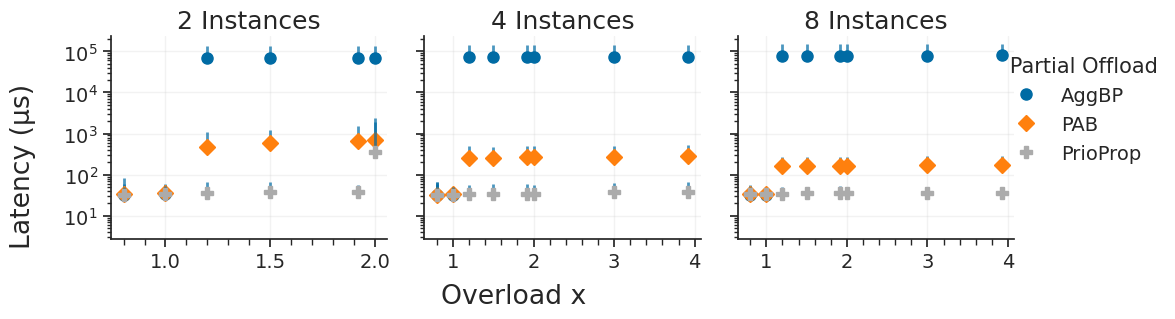

In [53]:
t_df = combined_df.copy()
t_df = t_df[t_df['IPv4 :Raw priority'] == '0x0']

# --- filter ---
t_df = t_df[t_df["Repeat"] == 5]
t_df = t_df[t_df["N Flows"] == 4000]

# --- aggregate by Mode, Instance, Overload ---
g = (
    t_df.groupby(["Mode", "Instance", "Overload"])
    .agg(
        lat_avg=("Cut-Through Avg Latency (ns)", "mean"),
        lat_max=("Cut-Through Max Latency (ns)", "mean"),
    )
    .reset_index()
)

# ns → µs
g[['lat_avg', 'lat_max']] /= 1e3

mode_display = {
    "aggbp": "AggBP",
    "pab": "PAB",
    "prioprop": "PrioProp",
}

instances = np.sort(g["Instance"].unique())
instances = instances[instances != 1]   # drop 4, keep 8

modes = g["Mode"].unique()
overloads = np.sort(g["Overload"].unique())
print(instances)
# x_pos = np.arange(1, len(overloads) + 1)
x_pos = overloads

# layout
n = len(instances)
ncols = min(3, n)
nrows = 1

# dodge by mode (within each overload) inside each instance panel
x_base = np.arange(len(overloads))
mode_offsets = np.linspace(-0.18, 0.18, len(modes))
mode_to_marker = {
    m: mk for m, mk in zip(modes, ["o", "s", "^", "D", "P", "X", "v", "*"])
}

fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3.6 * nrows), sharey=True)
axes = np.atleast_1d(axes).ravel()

# categorical positions 1..N
# x_pos = np.arange(1, len(overloads) + 1)

for ax, inst in zip(axes, instances):
    gi = g[g["Instance"] == inst]
        
    for off, mode in zip(mode_offsets, modes):
        if mode not in mode_display:
            continue

            
        gg = gi[gi["Mode"] == mode].set_index("Overload").reindex(overloads)

        x = x_pos + 0  # apply dodge (you had +0 before)

        ax.vlines(x, gg["lat_avg"], gg["lat_max"], linewidth=2, alpha=0.7)
        ax.plot(
            x, gg["lat_avg"],
            linestyle="None",
            marker=mode_to_marker[mode],
            label=mode_display.get(mode, str(mode)) if inst == instances[0] else None,
        )

    ax.set_title(f"{inst} Instances")
    ax.set_yscale("symlog")
    ax.grid(True, which="major", alpha=0.25)    

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.supxlabel("Overload x", y=0.1)
fig.supylabel("Latency (µs)")
# fig.suptitle("Cut-Through Latency by Mode, split by Instance", y=1.02)

# one legend for the whole figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="   Partial Offload",
    frameon=False,
    loc="upper right",
    bbox_to_anchor=(1.13, 0.85),
)

for ax in axes:
    ax.xaxis.set_major_locator(ticker.AutoLocator())
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())

    # y is log -> use LogLocator, and make minors actually show
    ax.minorticks_on()  # important: ensures minor ticks are enabled

    ax.yaxis.set_minor_locator(
        ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1)
    )
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())  # no minor labels

    # if you want to SEE them (gridlines), don't disable minor grid:
    ax.grid(True, which="major", alpha=0.25)
    ax.grid(False, which="minor", alpha=0)

    # make minor ticks visually obvious
    ax.tick_params(axis="y", which="minor", length=3)

plt.tight_layout()
plt.show()

# fig.savefig('/home/rubinhus/Documents/phd/thesis/backpressure/plots/latency_motivation_instance_partial_offload.pdf', bbox_inches="tight")
# fig.savefig('/home/rubinhus/Documents/phd/thesis/backpressure/plots/latency_pab_instance_partial_offload.pdf', bbox_inches="tight")

1
2
4


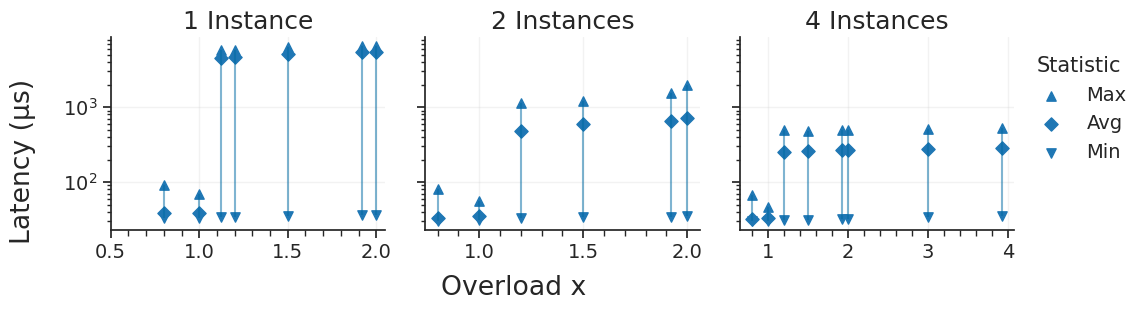

In [66]:
mode_sel = "pab"  # <-- pick your Mode here

t_df = combined_df.copy()
t_df = t_df[t_df["IPv4 :Raw priority"] == "0x0"]
t_df = t_df[t_df["Mode"] == mode_sel]
t_df = t_df[t_df["Repeat"] == 5]

g = (
    t_df.groupby(["Instance", "Overload"])
    .agg(
        lat_min=("Cut-Through Min Latency (ns)", "mean"),
        lat_avg=("Cut-Through Avg Latency (ns)", "mean"),
        lat_max=("Cut-Through Max Latency (ns)", "mean"),
    )
    .reset_index()
)

# ns -> µs
g[["lat_min", "lat_avg", "lat_max"]] /= 1e3

instances = np.sort(g["Instance"].unique())
overloads = np.sort(g["Overload"].unique())

n = len(instances)
ncols = min(3, n)
nrows = 1

fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3.5 * nrows), sharey=True)
axes = np.atleast_1d(axes).ravel()

mode_to_marker = {
    m: mk for m, mk in zip(modes, ["o", "s", "^", "D", "P", "X", "v", "*"])
}

stat_map = {
    "lat_max": ("Max", "^"),
    "lat_avg": ("Avg", "D"),
    "lat_min": ("Min", "v"),
    
    
}

for ax, inst in zip(axes, instances):
    print(inst)
    gg = g[g["Instance"] == inst].set_index("Overload").reindex(overloads)

    # Avg + Max lines
    # ax.plot(overloads, gg['lat_avg'], marker='o', linewidth=2, label='Avg')

    # optional: show the gap (Avg -> Max) as whiskers

    for col, (label, marker) in stat_map.items():
        ax.scatter(overloads, gg[col], label=label, marker=marker, s=45, color='tab:blue')
    ax.vlines(overloads, gg["lat_min"], gg["lat_max"], linewidth=1.5, alpha=0.5)


    # ax.plot(overloads, gg['lat_max'], marker='^', linewidth=2, label='Max')
    ax.set_title(f"{inst} Instance" if int(inst) == 1 else f"{inst} Instances")
    ax.grid(True, which="both", alpha=0.25)

# turn off extra axes
for ax in axes[len(instances) :]:
    ax.axis("off")

axes[0].set_xlim(0.5, 2.05)

fig.supxlabel("Overload x", y=0.1)
fig.supylabel("Latency (µs)")

# fig.suptitle(f'{mode_sel.upper()} Partial Offload Avg/ Max Latency', y=0.9)



for ax in axes:
    ax.set_yscale("log")
    ax.xaxis.set_major_locator(ticker.AutoLocator())
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())

    # y is log -> use LogLocator, and make minors actually show
    ax.minorticks_on()  # important: ensures minor ticks are enabled

    ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10)))
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())  # no minor labels

    # if you want to SEE them (gridlines), don't disable minor grid:
    ax.grid(True, which="major", alpha=0.25)
    ax.grid(False, which="minor", alpha=0)

    # make minor ticks visually obvious
    ax.tick_params(axis="y", which="minor", length=3)


# one legend (from first active axis)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    frameon=False,
    title="Statistic",
    loc="upper right",
    bbox_to_anchor=(1.1, 0.85),
)

plt.tight_layout()
sns.despine()
plt.show()

# fig.savefig('/home/rubinhus/Documents/phd/thesis/backpressure/plots/PAB_latency_overload.pdf', bbox_inches="tight")

In [245]:
plt.rcParams.update({'font.size': 24})

In [176]:
t_df = combined_df.copy()
t_df = t_df[t_df["IPv4 :Raw priority"] == "0x0"]
# t_df = t_df[t_df["Mode"] == mode_sel]
t_df = t_df[t_df["Repeat"] == 5]
# t_df = t_df[t_df["Instance"] == 2]
t_df = t_df[t_df['N Flows'] == 200]

# ['Loss %'].describe()
t_df.groupby(["Mode",'Instance','Overload'])[["Cut-Through Avg Latency (ns)"]].describe()

Cut-Through Avg Latency (ns)            \
                                                            count      mean   
Mode               Instance Overload                                          
freerunswscheduler 1        0.80                              5.0   37955.0   
                            1.00                              5.0  275281.4   
                            1.12                              5.0  345867.8   
                            1.20                              5.0  344370.8   
                            1.50                              5.0  336712.4   
                            1.92                              5.0  322430.4   
                            2.00                              5.0  320402.0   
pab                1        0.80                              5.0   38260.0   
                            1.00                              5.0   38940.8   
                            1.12                              5.0  106142.8   
                            1.20                              5.0  106956.8   
                            1.50                              5.0  109986.2   
                            1.92                              5.0  116208.0   
                            2.00                              5.0  117754.0   

                                                                       \
                                              std       min       25%   
Mode               Instance Overload                                    
freerunswscheduler 1        0.80        34.583233   37901.0   37950.0   
                            1.00      1460.813404  272670.0  275842.0   
                            1.12       678.575125  345002.0  345343.0   
                            1.20       120.387707  344195.0  344331.0   
                            1.50       148.271036  336504.0  336623.0   
                            1.92       289.969481  322072.0  322298.0   
                            2.00       261.872106  319966.0  320393.0   
pab                1        0.80       205.082910   37931.0   38187.0   
                            1.00        38.976916   38899.0   38903.0   
                            1.12        14.254824  106128.0  106129.0   
                            1.20        25.252723  106925.0  106934.0   
                            1.50        18.886503  109963.0  109973.0   
                            1.92        94.278842  116137.0  116146.0   
                            2.00        40.546270  117685.0  117753.0   

                                                                    
                                           50%       75%       max  
Mode               Instance Overload                                
freerunswscheduler 1        0.80       37964.0   37964.0   37996.0  
                            1.00      275954.0  275963.0  275978.0  
                            1.12      346152.0  346172.0  346670.0  
                            1.20      344375.0  344437.0  344516.0  
                            1.50      336744.0  336839.0  336852.0  
                            1.92      322327.0  322688.0  322767.0  
                            2.00      320465.0  320533.0  320653.0  
pab                1        0.80       38372.0   38399.0   38411.0  
                            1.00       38953.0   38959.0   38990.0  
                            1.12      106143.0  106157.0  106157.0  
                            1.20      106972.0  106974.0  106979.0  
                            1.50      109988.0  109996.0  110011.0  
                            1.92      116192.0  116195.0  116370.0  
                            2.00      117768.0  117777.0  117787.0

(2,)
2 50%= 550.1533379748009 99%= 892.6103080567991
(4,)
4 50%= 233.01154262156885 99%= 378.0280935963449
(8,)
8 50%= 140.35542323909416 99%= 193.871602149112


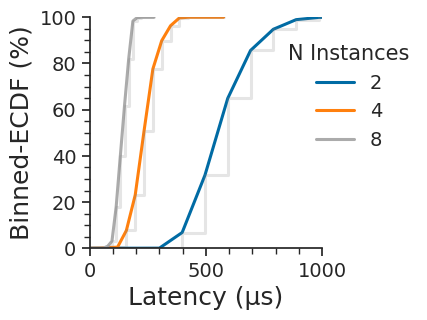

In [397]:
fig, ax1 = plt.subplots(nrows=1, ncols=1, figsize=[3, 3])

mode_sel = "pab"  # <-- pick your Mode here

t_df = combined_df.copy()
t_df = t_df[t_df["IPv4 :Raw priority"] == "0x0"]
t_df = t_df[t_df["Mode"] == mode_sel]
t_df = t_df[t_df["Repeat"] == 30]
t_df = t_df[t_df["Overload"] == 1.5]
# t_df = t_df[t_df["Instance"] == 8]
t_df = t_df[t_df["N Flows"] == 4000]

maximums_nusers = {
    (2,): 1500,
    (4,): 600,
    (8,): 300,

}
groups = group_and_clean(t_df, maximums_nusers, ["Instance"])

# ax1.set_xscale('logit')
# ax1.set_prop_cycle(cycler(color=okabe_ito))

draw_ecdf_plots(
    ax1,
    groups,
    {"column": "IPv4 :Raw priority", "name": "0x0"},
    [0, 1000],
    False,
    None,
    '.',
    True,
)

leg = fig.legends[0]
handles = leg.legend_handles
labels = [t.get_text() for t in leg.get_texts()]
leg.remove()

fig.legend(
    handles,
    labels,
    loc="upper right",
    title='N Instances',
    bbox_to_anchor=(1.25, 0.85),
    frameon=False,
)# leg.set_title(title="N Instances")


# fig.savefig('/home/rubinhus/Documents/phd/thesis/backpressure/plots/PAB_ECDF_instances.pdf', bbox_inches="tight")

50%= 140.35542323909416 99%= 193.871602149112
50%= 425.74393724140475 99%= 693.9814379119538
50%= 777.6881796925044 99%= 1261.3558694000224


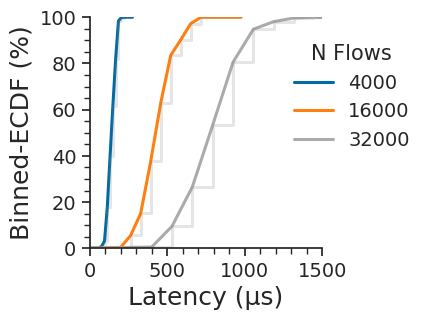

In [196]:
fig, ax1 = plt.subplots(nrows=1, ncols=1, figsize=[3, 3])

mode_sel = "pab"  # <-- pick your Mode here

t_df = combined_df.copy()
t_df = t_df[t_df["IPv4 :Raw priority"] == "0x0"]
t_df = t_df[t_df["Mode"] == mode_sel]
t_df = t_df[t_df["Repeat"] == 30]
t_df = t_df[t_df["Instance"] == 8]

maximums_nusers = {
    (4000,): 300,
    (16000,): 1000,
    (32000,): 1500,

}
groups = group_and_clean(t_df, maximums_nusers, ["N Flows"])

# ax1.set_xscale('logit')
# ax1.set_prop_cycle(cycler(color=okabe_ito))

draw_ecdf_plots(
    ax1,
    groups,
    {"column": "IPv4 :Raw priority", "name": "0x0"},
    [0, 1500],
    False,
    None,
    '.',
    True,
)

leg = fig.legends[0]
handles = leg.legend_handles
labels = [t.get_text() for t in leg.get_texts()]
leg.remove()

fig.legend(
    handles,
    labels,
    loc="upper right",
    title='N Flows',
    bbox_to_anchor=(1.25, 0.85),
    frameon=False,
)# leg.set_title(title="N Instances")


# fig.savefig('/home/rubinhus/Documents/phd/thesis/backpressure/plots/PAB_ECDF_flows.pdf', bbox_inches="tight")

In [67]:
t_df = combined_df[combined_df["IPv4 :Raw priority"] == "0x0"]
t_df[t_df["Overload"] == 1.5].groupby(["Mode", "Instance", "Overload"])[
    "Cut-Through Avg Latency (ns)"
].describe() / 1e3

count          mean          std  \
Mode               Instance Overload                                     
aggbp              1        1.5       0.005   7380.986200  4597.917158   
                   2        1.5       0.010  69698.092500     8.262481   
                   4        1.5       0.020  72490.957550     2.608050   
                   8        1.5       0.040  78042.956700     4.802340   
freerun            1        1.5       0.005   1403.678000     1.081555   
                   2        1.5       0.010   2805.062600     0.983699   
                   4        1.5       0.020   5625.474500     1.192120   
                   8        1.5       0.040  11235.846075     2.035610   
freerunswscheduler 1        1.5       0.015   6414.307733  4508.366843   
pab                1        1.5       0.005  10296.050000     1.794022   
                   2        1.5       0.070    588.096329     6.443881   
                   4        1.5       0.140    259.606557     0.972237   
                   8        1.5       0.920    446.492270   263.479423   
prioprop           1        1.5       0.005     43.539800     0.066417   
                   2        1.5       0.010     37.728400     0.141038   
                   4        1.5       0.020     34.181100     0.090113   
                   8        1.5       0.040     34.991500     0.179324   

                                            min          25%         50%  \
Mode               Instance Overload                                       
aggbp              1        1.5        4267.312   4513.87300   5000.6130   
                   2        1.5       69688.959  69692.57650  69695.6905   
                   4        1.5       72486.105  72489.86000  72491.4500   
                   8        1.5       78034.310  78039.63025  78042.4600   
freerun            1        1.5        1402.948   1402.97100   1403.4310   
                   2        1.5        2803.901   2804.33600   2804.9535   
                   4        1.5        5623.810   5624.62275   5625.2165   
                   8        1.5       11231.564  11234.35650  11235.9280   
freerunswscheduler 1        1.5         336.504    336.84550   8590.0130   
pab                1        1.5       10293.592  10295.43700  10295.5890   
                   2        1.5         583.442    585.57100    586.5140   
                   4        1.5         258.121    258.82750    259.4875   
                   8        1.5         162.976    164.50375    454.6560   
prioprop           1        1.5          43.472     43.49200     43.5160   
                   2        1.5          37.522     37.65125     37.7240   
                   4        1.5          34.038     34.09750     34.1990   
                   8        1.5          34.581     34.86550     34.9955   

                                              75%        max  
Mode               Instance Overload                          
aggbp              1        1.5        7954.11700  15169.016  
                   2        1.5       69703.43675  69712.973  
                   4        1.5       72492.50875  72494.939  
                   8        1.5       78046.11375  78054.870  
freerun            1        1.5        1403.47900   1405.561  
                   2        1.5        2805.54575   2807.164  
                   4        1.5        5626.52525   5627.660  
                   8        1.5       11237.26800  11239.761  
freerunswscheduler 1        1.5       10312.02000  10332.285  
pab                1        1.5       10297.75900  10297.873  
                   2        1.5         587.61600    611.002  
                   4        1.5         260.37200    261.403  
                   8        1.5         800.10925    807.053  
prioprop           1        1.5          43.59400     43.625  
                   2        1.5          37.78075     37.984  
                   4        1.5          34.24875     34.334  
                   8        1.5          35.10050   

In [230]:
base_dir = "/home/rubinhus/Documents/phd/thesis/backpressure/data/ninstances_nflows/"
pattern = "**/*Latency_Bins cross page.csv"

all_dfs = []

csv_files = glob.glob(os.path.join(base_dir, pattern), recursive=True)

for path in csv_files:
   
    # Split folder name into components safely
    folder = path.split("/")
    # Some directories may not follow exact pattern: guard length
    
    # parts = folder
    # print(folder)
    try:
        #ninstances = parts[-1] if len(parts) > 1 else None
        #ntc = parts[-2] if len(parts) > 2 else None
        # overload = float(parts[-4].strip("_"))
        # print(overload)
        overload =  float(folder[-4].split('_')[0])
        repeat = int(folder[-4].split('_')[1].strip('x'))
        instances = int(folder[-5].split('_')[0].strip('instances'))
        mode = folder[-5].split('_')[1]
        framesize = int(folder[-2])
        nflows = int(folder[-3])*instances
                          
        df = pd.read_csv(path)
        #df["Instance"] = int(ninstances.strip('instance'))
        #df["TC"] = int(ntc.strip('ntc'))
                          
        df['Overload'] = overload
        df['Instance'] = instances
        df['Mode'] = mode
        df['Framesize'] = framesize
        df['Repeat'] = repeat
        df['N Flows'] = nflows

        all_dfs.append(df)
    except Exception as e:
        print(f"Failed to parse {folder_name}: {e}")

# Combine all datasets
combined_df = pd.concat(all_dfs, ignore_index=True)

# Optional: sort or save
# combined_df = combined_df.sort_values(by="source")
# combined_df.to_csv("/home/rubinhus/combined_aggregateresults.csv", index=False)

print(f"Loaded {len(combined_df)} rows from {len(all_dfs)} files")

Loaded 400 rows from 25 files


In [241]:
t_df.groupby(['N Flows'])['Cut-Through Max Latency (ns)'].describe()/1E3

,count,mean,std,min,25%,50%,75%,max
N Flows,,,,,,,,
4000,0.12,274.460342,5.992220,265.052,271.00275,273.2620,276.31000,302.027
16000,0.04,826.074375,49.534873,769.747,789.28825,806.2210,859.88150,942.737
32000,0.04,1501.192900,52.212788,1444.757,1470.94125,1479.8085,1503.76125,1697.107


50%= 140.54923731396775 99%= 194.43007168937257
50%= 266.6056328233735 99%= 275.85425265646745
50%= 267.0101965481154 99%= 275.8623439309623


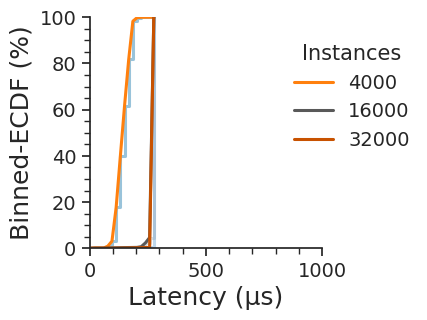

In [242]:
fig, ax1 = plt.subplots(nrows=1, ncols=1, figsize=[3, 3])

mode_sel = "pab"  # <-- pick your Mode here

t_df = combined_df.copy()
t_df = t_df[t_df["IPv4 :Raw priority"] == "0x0"]
t_df = t_df[t_df["Mode"] == mode_sel]
t_df = t_df[t_df["Repeat"] == 5]

maximums_nusers = {
    (4000,): 300,
    (32000,): 300,
    (16000,): 300,

}
groups = group_and_clean(t_df, maximums_nusers, ["N Flows"])

# ax1.set_xscale('logit')

draw_ecdf_plots(
    ax1,
    groups,
    {"column": "IPv4 :Raw priority", "name": "0x0"},
    [0, 1000],
    False,
    None,
    '.',
    True,
)


leg = fig.legends[0]
handles = leg.legend_handles
labels = [t.get_text() for t in leg.get_texts()]
leg.remove()

fig.legend(
    handles,
    labels,
    loc="upper right",
    title='Instances',
    bbox_to_anchor=(1.25, 0.85),
    frameon=False,
)# leg.set_title(title="N Instances")


# fig.savefig('/home/rubinhus/Documents/phd/thesis/backpressure/plots/PAB_ECDF_instances.pdf', bbox_inches="tight")

In [ ]:
t_df = combined_df# [combined_df['Mode'] == 'aggbp']
t_df = t_df[t_df['IPv4 :Raw priority'] == '0x0']
# t_df.groupby(['Instance', 'Overload'])['Loss %'].describe()
t_df.groupby(['Mode','Instance', 'Overload'])[['Cut-Through Avg Latency (ns)', 'Cut-Through Max Latency (ns)']].mean()/1E3

In [78]:
base_dir = "/home/rubinhus/Documents/phd/thesis/backpressure/data/revision/tc_overhead_perf/perf/"
pattern = "*.csv"

all_dfs = []

csv_files = glob.glob(os.path.join(base_dir, pattern))

for path in csv_files:
    if 'cache' not in path:
        continue
    filename = os.path.basename(path)
    print(filename)
    
    try:
        # Example: 2tc_default_1.12.csv
        name = filename.replace(".csv", "")
        parts = name.split("_")
        
        # Parse metadata
        ntc = int(parts[0].replace("tc", ""))       # 2tc -> 2
        experiment = parts[1]                       # default / pab
        overload = float(parts[3])                  # 1.12
        
        # Read file (perf format uses ';' as separator)
        df = pd.read_csv(path, sep=";", comment="#", header=None)
        
        # Assign column names (based on provided structure)
        df.columns = [
            "Value", "Empty1", "Metric", "Percent",
            "Time", "Coverage", "IPC", "Description"
        ]
        
        # Add metadata columns (align with previous structure)
        df["Instance"] = None          # not available
        df["N TC"] = ntc
        df["Mode"] = experiment
        df["Repeat"] = None            # not available
        df["Overload"] = overload
        
        all_dfs.append(df)
    
    except Exception as e:
        print(f"Failed to parse {filename}: {e}")

# Combine all datasets
perf_df = pd.concat(all_dfs, ignore_index=True)

4tc_default_cache_1.5.csv
4tc_default_cache_1.12.csv
8tc_default_cache_1.5.csv
8tc_pab_cache_1.5.csv
2tc_default_cache_1.5.csv
4tc_pab_cache_1.12.csv
8tc_default_cache_1.12.csv
2tc_pab_cache_1.5.csv
2tc_pab_cache_1.12.csv
8tc_pab_cache_1.12.csv
4tc_pab_cache_1.5.csv
2tc_default_cache_1.12.csv


In [110]:
p_df = perf_df.copy()

# Clean columns
p_df["IPC"] = pd.to_numeric(p_df["IPC"], errors="coerce")

p_df["Percent"] = (
    p_df["Percent"]
    .astype(str)
    .str.replace("%", "", regex=False)
)
p_df["Percent"] = pd.to_numeric(p_df["Percent"], errors="coerce")

# --- Extract IPC from instructions rows ---
ipc_df = p_df[p_df["Metric"] == "instructions"].copy()
ipc_grouped = ipc_df.groupby(
    ["Mode", "Overload", "N TC"],
    dropna=False
)[["IPC", "Percent"]].mean()

# --- Extract cache miss % from cache-misses rows ---
# The "IPC" column holds "% of all cache refs" for cache-misses rows
cm_df = p_df[p_df["Metric"] == "cache-misses"].copy()
cm_df = cm_df.rename(columns={"IPC": "CacheMissPct", "Value": "CacheMissCount"})
cm_df["CacheMissCount"] = pd.to_numeric(cm_df["CacheMissCount"], errors="coerce")

cm_grouped = cm_df.groupby(
    ["Mode", "Overload", "N TC"],
    dropna=False
)[["CacheMissPct", "CacheMissCount"]].mean()

# --- Combine ---
result_df = ipc_grouped.join(cm_grouped)

result_df = result_df.reset_index()

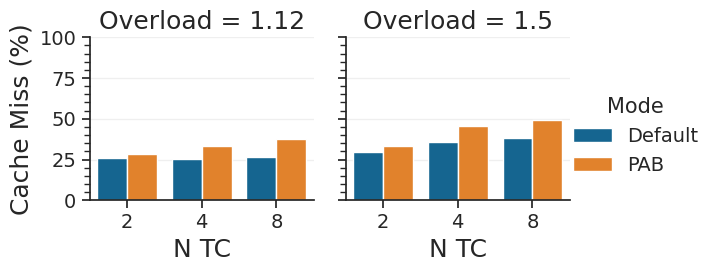

In [85]:
g = sns.catplot(
    data=result_df,
    x='N TC',
    y='CacheMissPct',
    hue='Mode',
    col='Overload',
    kind='bar',
    height=3,
)

# Axis labels
g.set_axis_labels("N TC", "Cache Miss (%)")

# Column titles
g.set_titles("Overload = {col_name}")

for ax in g.axes.flat:
    # Log-scale minor ticks
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(True, which="major", axis="y", alpha=0.3)
    # ax.yaxis.set_minor_formatter(ticker.NullFormatter())
    
g.set(ylim=[0, 100])
# Optional: rename legend labels
for t in g._legend.texts:
    if t.get_text() == "default":
        t.set_text("Default")
    elif t.get_text() == "pab":
        t.set_text("PAB")

In [113]:
pps_df = combined_df.groupby(
    ["Mode", "Overload", "N TC"],
    dropna=False
)[["Rx Frame Rate"]].mean()
CPU_FREQ=2.2E9
cpp_df = CPU_FREQ/pps_df.astype(int)
cpp_df = cpp_df.rename(columns={"Rx Frame Rate": "IPP"})

ipc_df = perf_df.copy()

ipc_df["IPC"] = pd.to_numeric(ipc_df["IPC"], errors="coerce")

ipc_df = ipc_df[ipc_df["Metric"] == "instructions"]

ipc_df = ipc_df.groupby(["Mode", "Overload", "N TC"],
    dropna=False
)[["IPC"]].mean()

merged = cpp_df.merge(
    ipc_df,
    left_index=True,
    right_index=True,
    how="left"
)

merged["CPP"] = merged["IPP"] / merged["IPC"]
merged#.to_csv('/home/rubinhus/cpp.csv')

merged['IPP'] = merged['IPP'].astype(int)
merged['CPP'] = merged['CPP'].round(2)

pivot = merged.reset_index().pivot_table(
    index=["Overload", "N TC"],
    columns="Mode",
    values="CPP"
)

pivot["delta_CPP"] = pivot.get("pab") - pivot.get("default")

# relative difference (normalized)
pivot["rel_delta_CPP"] = (
    pivot["delta_CPP"] / pivot.get("default")
)

merged = merged.reset_index().merge(
    pivot[["delta_CPP", "rel_delta_CPP"]],
    on=["Overload", "N TC"],
    how="left"
).set_index(["Mode", "N TC", "Overload"])

merged["delta_CPP"] = merged["delta_CPP"].round(2)
merged["rel_delta_CPP"] = merged["rel_delta_CPP"].round(3)*100

merged# .to_csv('/home/rubinhus/code/cpp.csv')

IPP   IPC      CPP  delta_CPP  rel_delta_CPP
Mode    N TC Overload                                               
default 2    1.12      1350  2.43   555.75     -26.86           -4.8
        4    1.12      4325  2.38  1817.48    -140.95           -7.8
        8    1.12      8976  2.53  3547.97     -99.49           -2.8
        2    1.50      1350  2.42   558.05       3.10            0.6
        4    1.50      4325  2.36  1832.87      35.69            1.9
        8    1.50      8651  2.54  3406.01     576.75           16.9
pab     2    1.12      1327  2.51   528.89     -26.86           -4.8
        4    1.12      4241  2.53  1676.53    -140.95           -7.8
        8    1.12      8483  2.46  3448.48     -99.49           -2.8
        2    1.50      1380  2.46   561.15       3.10            0.6
        4    1.50      4241  2.27  1868.56      35.69            1.9
        8    1.50      8483  2.13  3982.76     576.75           16.9

In [297]:
100*(3406.01-3982.76)/3406.01

-16.933303190536726

In [105]:
base_dir = "/home/rubinhus/Documents/phd/thesis/backpressure/data/revision/tc_overhead_perf/"
pattern = "**/*Latency_Bins cross page.csv"

all_dfs = []

csv_files = glob.glob(os.path.join(base_dir, pattern), recursive=True)

for path in csv_files:
   
    # Split folder name into components safely
    folder = path.split("/")
    # print(folder)
    try:
        ninstances = int(folder[-6].split("_")[0].strip('instances'))
        experiment = folder[-6].split("_")[1]
        ntc = int(folder[-4].split("_")[0].strip('tc'))
        repeat = int(folder[-4].split("_")[1].strip('x'))
#        

        overload = float(folder[-5])
        # excase = folder[-5].split("_")[1]
        
        df = pd.read_csv(path)
        df["Instance"] = ninstances
        df["N TC"] = ntc
        df["Mode"] = experiment
        df["Repeat"] = repeat
        df["Overload"] = overload
        # df['Case'] = excase
        
        all_dfs.append(df)
    except Exception as e:
        print(f"Failed to parse {folder_name}: {e}")

# Combine all datasets
combined_df = pd.concat(all_dfs, ignore_index=True)

# Optional: sort or save
# combined_df = combined_df.sort_values(by="source")
# combined_df.to_csv("/home/rubinhus/combined_aggregateresults.csv", index=False)

print(f"Loaded {len(combined_df)} rows from {len(all_dfs)} files")

Loaded 280 rows from 60 files


In [106]:
# combined_df = combined_df[combined_df['Instance'] == 2]
p_df = combined_df[combined_df['IPv4 :Raw priority'] == '0x0']
# p_df = p_df[p_df['Case'] == 'balanced']

p_df = p_df[p_df['Repeat'] == 5]
((p_df.groupby(["Mode", 'Overload',  "N TC"])[
    ["Loss %"]
].mean())).round(3)

Loss %
Mode    Overload N TC        
default 1.12     2      0.000
                 4      0.002
                 8      0.003
        1.50     2      0.000
                 4      0.002
                 8      0.006
pab     1.12     2      0.000
                 4      0.000
                 8      0.000
        1.50     2      0.000
                 4      0.001
                 8     17.144

In [108]:
# combined_df = combined_df[combined_df['Instance'] == 2]
p_df = combined_df[combined_df['IPv4 :Raw priority'] == '0x0']

p_df = p_df[p_df['Repeat'] == 5]
((p_df.groupby(["Mode", 'Overload',  "N TC"])[
    #["Loss %", "Cut-Through Avg Latency (ns)", "Cut-Through Max Latency (ns)"]
    ["Cut-Through Min Latency (ns)", "Cut-Through Avg Latency (ns)", "Cut-Through Max Latency (ns)"]
].mean())/1E3).round(3)

Cut-Through Min Latency (ns)  \
Mode    Overload N TC                                 
default 1.12     2                           33.202   
                 4                           32.770   
                 8                           32.762   
        1.50     2                           32.602   
                 4                           33.524   
                 8                           33.854   
pab     1.12     2                           32.563   
                 4                           33.654   
                 8                           33.783   
        1.50     2                           32.412   
                 4                           34.375   
                 8                           33.791   

                       Cut-Through Avg Latency (ns)  \
Mode    Overload N TC                                 
default 1.12     2                          249.150   
                 4                         1048.217   
                 8                         2219.313   
        1.50     2                          235.553   
                 4                         1441.650   
                 8                         3657.370   
pab     1.12     2                          103.324   
                 4                          106.581   
                 8                          113.378   
        1.50     2                          108.932   
                 4                          304.817   
                 8                        12952.140   

                       Cut-Through Max Latency (ns)  
Mode    Overload N TC                                
default 1.12     2                         3147.725  
                 4                        12580.844  
                 8                        29331.773  
        1.50     2                         2523.310  
                 4                        18452.993  
                 8                        47215.053  
pab     1.12     2                          217.754  
                 4                          185.023  
                 8                          210.064  
        1.50     2                          212.939  
                 4                          785.251  
                 8                        14560.117

In [14]:

t_df = combined_df.copy()
# t_df = t_df[t_df["IPv4 :Raw priority"] == "0x0"]
t_df = t_df[t_df["Mode"] == "freerunswscheduler"]
t_df = t_df[t_df["Repeat"] == 5]
# t_df = t_df[t_df["N TC"] != 8]
t_df = t_df[t_df["Overload"] == 1.12]

t_df.groupby(["Case", "N TC", "IPv4 :Raw priority"])[['Tx Frames', 'Loss %']].describe()
# t_df['Loss %'].describe()

Tx Frames                             \
                                       count         mean           std   
Case       N TC IPv4 :Raw priority                                        
balanced   2    0x0                      5.0    9812285.0  1.472272e+05   
                0x1                      5.0  127559704.2  1.913954e+06   
           4    0x0                      5.0    9812351.0  1.472049e+05   
                0x1                      5.0   42520184.8  6.378884e+05   
                0x2                      5.0   42520184.8  6.378884e+05   
                0x3                      5.0   42520184.6  6.378883e+05   
           8    0x0                      5.0    9746303.8  1.802112e+05   
                0x1                      5.0   18100278.0  3.346779e+05   
                0x2                      5.0   18100278.0  3.346779e+05   
                0x3                      5.0   18100277.8  3.346777e+05   
                0x4                      5.0   18100277.6  3.346776e+05   
                0x5                      5.0   18100277.6  3.346776e+05   
                0x6                      5.0   18100277.4  3.346778e+05   
                0x7                      5.0   18100277.2  3.346776e+05   
unbalanced 4    0x0                      5.0    9746257.8  1.803723e+05   
                0x1                      5.0   32487524.6  6.012412e+05   
                0x2                      5.0   32487524.6  6.012412e+05   
                0x3                      5.0   61726296.8  1.142358e+06   
           8    0x0                      5.0    9746300.6  1.804907e+05   
                0x1                      5.0   13227122.2  2.449518e+05   
                0x2                      5.0   13227122.2  2.449518e+05   
                0x3                      5.0   13227122.0  2.449521e+05   
                0x4                      5.0   13227121.6  2.449517e+05   
                0x5                      5.0   13227121.4  2.449516e+05   
                0x6                      5.0   13227121.2  2.449518e+05   
                0x7                      5.0   47339171.8  8.766698e+05   

                                                                           \
                                            min          25%          50%   
Case       N TC IPv4 :Raw priority                                          
balanced   2    0x0                   9548917.0    9877967.0    9878100.0   
                0x1                 124135920.0  128413573.0  128415293.0   
           4    0x0                   9549023.0    9877977.0    9878157.0   
                0x1                  41379096.0   42804565.0   42805344.0   
                0x2                  41379096.0   42804565.0   42805344.0   
                0x3                  41379096.0   42804565.0   42805344.0   
           8    0x0                   9548753.0    9549032.0    9877608.0   
                0x1                  17733398.0   17733916.0   18344129.0   
                0x2                  17733398.0   17733916.0   18344129.0   
                0x3                  17733398.0   17733916.0   18344129.0   
                0x4                  17733398.0   17733916.0   18344128.0   
                0x5                  17733398.0   17733916.0   18344128.0   
                0x6                  17733398.0   17733915.0   18344128.0   
                0x7                  17733398.0   17733915.0   18344128.0   
unbalanced 4    0x0                   9548517.0    9548823.0    9877631.0   
                0x1                  31828390.0   31829407.0   32925436.0   
                0x2                  31828390.0   31829407.0   32925436.0   
                0x3                  60473941.0   60475873.0   62558328.0   
           8    0x0                   9548419.0    9548747.0    9877981.0   
                0x1                  12958568.0   12959014.0   13405831.0   
                0x2                  12958568.0   12959014.0   13405831.0   
           

In [15]:

t_df = combined_df.copy()
# t_df = t_df[t_df["IPv4 :Raw priority"] == "0x0"]
t_df = t_df[t_df["Mode"] == "pab"]
t_df = t_df[t_df["Repeat"] == 5]
# t_df = t_df[t_df["N TC"] != 8]
t_df = t_df[t_df["Overload"] == 1.12]

t_df.groupby(["Case", "N TC", "IPv4 :Raw priority"])[['Tx Frames','Loss %']].describe()
# t_df['Loss %'].describe()

Tx Frames                             \
                                       count         mean           std   
Case       N TC IPv4 :Raw priority                                        
balanced   2    0x0                      5.0    9746290.4  1.805777e+05   
                0x1                      5.0  126701773.8  2.347512e+06   
           4    0x0                      5.0    9878168.4  2.878651e+02   
                0x1                      5.0   42805393.6  1.247648e+03   
                0x2                      5.0   42805393.6  1.247648e+03   
                0x3                      5.0   42805393.0  1.247729e+03   
           8    0x0                      5.0    9812282.0  1.471803e+05   
                0x1                      5.0   18222808.8  2.733352e+05   
                0x2                      5.0   18222808.4  2.733350e+05   
                0x3                      5.0   18222808.4  2.733350e+05   
                0x4                      5.0   18222808.4  2.733350e+05   
                0x5                      5.0   18222808.0  2.733353e+05   
                0x6                      5.0   18222808.0  2.733353e+05   
                0x7                      5.0   18222808.0  2.733353e+05   
unbalanced 4    0x0                      5.0    9811818.4  1.471965e+05   
                0x1                      5.0   42517878.0  6.378518e+05   
                0x2                      5.0   42517877.8  6.378517e+05   
                0x3                      5.0   62141514.6  9.322447e+05   
           8    0x0                      5.0    9877982.0  2.768727e+02   
                0x1                      5.0   13405832.2  3.759670e+02   
                0x2                      5.0   13405832.2  3.759670e+02   
                0x3                      5.0   13405832.0  3.758723e+02   
                0x4                      5.0   13405831.6  3.756132e+02   
                0x5                      5.0   13405831.6  3.756132e+02   
                0x6                      5.0   13405831.4  3.760503e+02   
                0x7                      5.0   47978765.6  1.345321e+03   

                                                                           \
                                            min          25%          50%   
Case       N TC IPv4 :Raw priority                                          
balanced   2    0x0                   9548461.0    9548494.0    9877995.0   
                0x1                 124129992.0  124130415.0  128413933.0   
           4    0x0                   9877734.0    9878106.0    9878171.0   
                0x1                  42803510.0   42805123.0   42805407.0   
                0x2                  42803510.0   42805123.0   42805407.0   
                0x3                  42803509.0   42805123.0   42805406.0   
           8    0x0                   9548999.0    9877352.0    9878324.0   
                0x1                  17733854.0   18343653.0   18345459.0   
                0x2                  17733854.0   18343653.0   18345458.0   
                0x3                  17733854.0   18343653.0   18345458.0   
                0x4                  17733854.0   18343653.0   18345458.0   
                0x5                  17733853.0   18343653.0   18345458.0   
                0x6                  17733853.0   18343653.0   18345458.0   
                0x7                  17733853.0   18343653.0   18345458.0   
unbalanced 4    0x0                   9548508.0    9876491.0    9877878.0   
                0x1                  41376866.0   42798127.0   42804136.0   
                0x2                  41376866.0   42798127.0   42804135.0   
                0x3                  60473882.0   62551109.0   62559891.0   
           8    0x0                   9877498.0    9878049.0    9878074.0   
                0x1                  13405175.0   13405923.0   13405957.0   
                0x2                  13405175.0   13405923.0   13405957.0   
           

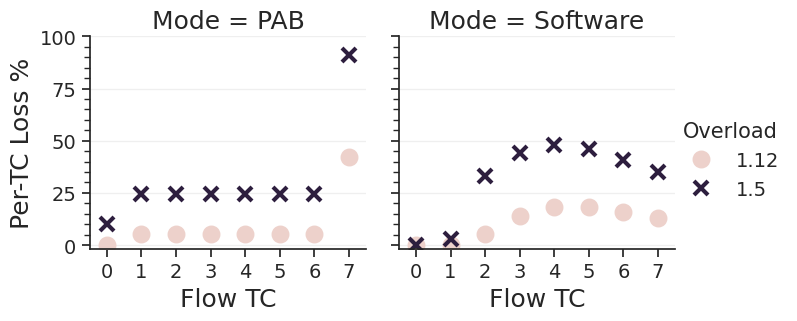

In [16]:
OVERLOAD = 1.12
mode_rename = {"freerunswscheduler": "Software", "pab": "PAB", }

t_df = combined_df.copy()

t_df = t_df[
#    (t_df["Repeat"] == 5)
    # (t_df["Overload"] == OVERLOAD) 
    # &     (t_df["Mode"].isin(["freerunswscheduler", "pab"])) &
    (t_df["Case"].isin(["balanced"])) & (t_df["N TC"].isin([8]))
]
t_df["Mode"] = t_df["Mode"].replace(mode_rename)

t_df["IPv4 :Raw priority"] = t_df["IPv4 :Raw priority"].apply(
    lambda x: int(x, 16) if pd.notna(x) else x
)

# Aggregate with mean + std
agg_df = (
    t_df
    .groupby(["N TC", "IPv4 :Raw priority", "Case", "Overload", "Mode"])["Loss %"]
    .agg(mean="mean", std="std")
    .reset_index()
)
agg_df["Mode_Case"] = agg_df["Mode"] + " | " + agg_df["Case"]
agg_df["Overload_Mode"] = agg_df["Overload"].astype(str) + " | " + agg_df["Mode"]

N_TC=4
g = sns.catplot(
    data=agg_df,
    col="Mode",
    x="IPv4 :Raw priority",
    y="mean",
    hue="Overload",
    # marker="Case",
    kind="point",
    sharex=False,
    markers=["o", "x", "s", "x"],  # adjust for combinations
    join=False,
    errorbar="sd",   # <-- correct std bars
    height=3.5,
    # jitter=True,
)

# plt.set_ylim([0,100])
g.set_axis_labels("Flow TC", "Per-TC Loss %")
# g.fig.suptitle(f"Per-TC Loss", y=1.02)

for ax in g.axes.flat:
    # Log-scale minor ticks
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(True, which="major", axis="y", alpha=0.3)
    # ax.yaxis.set_minor_formatter(ticker.NullFormatter())


for ax in g.axes.flat:
    ax.set_ylim(-2, 100)

plt.show()

# g.savefig('/home/rubinhus/Documents/phd/thesis/backpressure/plots/1instance_loss_ntc.pdf', bbox_inches="tight")

In [17]:
fig.set_constrained_layout(False)
plt.rcParams['figure.constrained_layout.use'] = False

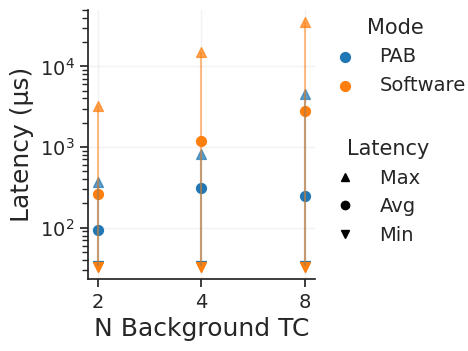

In [45]:
mode_rename = {"pab": "PAB", "default": "Software", "freerunswscheduler": "Software"}

mode_order = ["PAB", "Software"]

t_df = combined_df.copy()

t_df = t_df[
    (t_df["IPv4 :Raw priority"] == "0x0")
    & (t_df["Repeat"] == 5)
    & (t_df["Overload"] == 1.12)
    & (t_df["Mode"].isin(mode_rename.keys()))  # FIXED
]

# rename BEFORE grouping
t_df["Mode"] = t_df["Mode"].replace(mode_rename)

g = (
    t_df.groupby(["N TC", "Mode"])
    .agg(
        lat_min=("Cut-Through Min Latency (ns)", "mean"),
        lat_avg=("Cut-Through Avg Latency (ns)", "mean"),
        lat_max=("Cut-Through Max Latency (ns)", "mean"),
    )
    .reset_index()
)

# baseline correction
g[["lat_min", "lat_avg", "lat_max"]] -= 23.957

# ns -> µs
g[["lat_min", "lat_avg", "lat_max"]] /= 1e3

g = g.sort_values(["N TC", "Mode"])

ntcs = np.sort(g["N TC"].unique())
x = np.arange(len(ntcs))

palette = {"PAB": "tab:blue", "Software": "tab:orange"}

markers = {"PAB": "o", "Software": "o"}

fig, ax = plt.subplots(figsize=(7, 3.5))

for mode in mode_order:
    sub = g[g["Mode"] == mode]

    for _, row in sub.iterrows():
        x_idx = np.where(ntcs == row["N TC"])[0][0]

        ax.vlines(
            x_idx,
            row["lat_min"],
            row["lat_max"],
            color=palette[mode],
            alpha=0.5,
            linewidth=1.5,
        )

        ax.scatter(
            x_idx,
            row["lat_min"],
            color=palette[mode],
            marker="v",
            s=50,
            # label=mode if x_idx == 0 else None,
        )

        ax.scatter(
            x_idx,
            row["lat_avg"],
            color=palette[mode],
            marker=markers[mode],
            s=50,
            label=mode if x_idx == 0 else None,
        )

        ax.scatter(
            x_idx,
            row["lat_max"],
            color=palette[mode],
            marker="^",
            s=50,
            alpha=0.7,
            # label=mode if x_idx == 0 else None,
        )

ax.set_xticks(x)
ax.set_xticklabels(ntcs)

ax.set_xlabel("N Background TC")
ax.set_ylabel("Latency (µs)")
ax.set_yscale("log")

ax.grid(True, which="major", alpha=0.25)

ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10)))
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

marker_legend = [
    Line2D(
        [0], [0], marker="^", color="black", linestyle="None", markersize=6, label="Max     " # Geil
    ),
    Line2D(
        [0], [0], marker="o", color="black", linestyle="None", markersize=6, label="Avg"
    ),
    Line2D(
        [0], [0], marker="v", color="black", linestyle="None", markersize=6, label="Min"
    ),
]

legend1 = ax.legend(
    frameon=False,
    title="Mode",
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
    borderaxespad=0,
)
ax.add_artist(legend1)

ax.legend(
    handles=marker_legend,
    frameon=False,
    title="Latency",
    loc="upper left",
    bbox_to_anchor=(1.01, 0.55),
    borderaxespad=0,
)

fig.subplots_adjust(right=0.45)
# fig.tight_layout(rect=[0, 0, 0.65, 1])
# fig.tight_layout()
sns.despine()
# plt.show()

# fig.savefig('/home/rubinhus/Documents/phd/thesis/backpressure/plots/1instance_latency_ntc.pdf', bbox_inches="tight")

KeyError: 'Loss %'

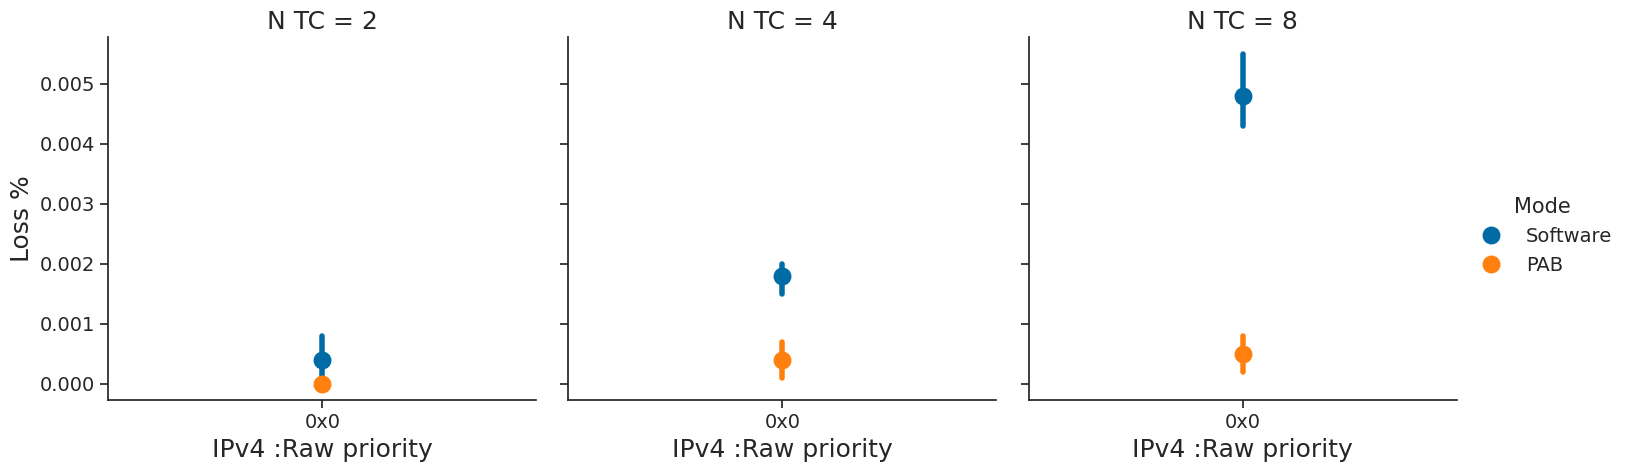

In [19]:
g = sns.catplot(
    data=t_df,
    col="N TC",
    x="IPv4 :Raw priority",
    y="Loss %",
    hue="Mode",
    kind="point",
    join=False,
)

# Overlay aggregate line per facet
for ax, (ntc, subdf) in zip(g.axes.flat, agg_df.groupby("N TC")):
    ax.plot(
        subdf["IPv4 :Raw priority"],
        subdf["Loss %"],
        linestyle="--",
        marker="o",
        label="Aggregate"
    )
    ax.legend()

g.set_axis_labels("Priority (int)", "Loss %")
g.fig.suptitle("Loss % with Aggregate", y=1.02)

plt.show()

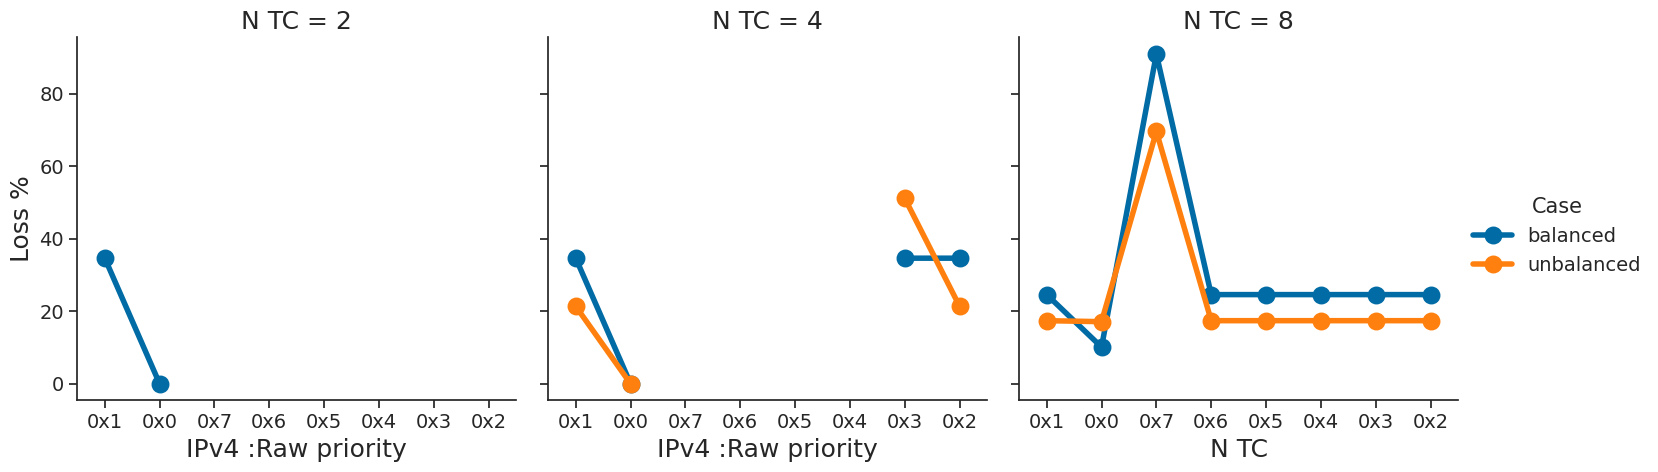

In [394]:
import seaborn as sns
import matplotlib.pyplot as plt

t_df = combined_df.copy()
# t_df = t_df["IPv4 :Raw priority"] == "0x0
t_df = t_df[t_df["Repeat"] == 5]
t_df = t_df[t_df["Overload"] == 1.5]

# plt.title("Loss % distribution by N TC")
plt.xlabel("N TC")
plt.ylabel("Loss %")
plt.show()

In [366]:

t_df = combined_df.copy()
# t_df = t_df[t_df["IPv4 :Raw priority"] == "0x0"]
t_df = t_df[t_df["Mode"] == "freerunswscheduler"]
t_df = t_df[t_df["Repeat"] == 5]
# t_df = t_df[t_df["N TC"] != 8]
t_df = t_df[t_df["Overload"] == 1.5]

t_df.groupby(["N TC", "IPv4 :Raw priority"])['Loss %'].describe()
# t_df['Loss %'].describe()

count     mean        std     min       25%      50%  \
N TC IPv4 :Raw priority                                                         
2    0x0                   5.0   0.0004   0.000548   0.000   0.00000   0.0000   
     0x1                   5.0  35.6632   0.006573  35.656  35.65600  35.6680   
4    0x0                  10.0   0.0025   0.000527   0.002   0.00200   0.0025   
     0x1                  10.0  14.7357   7.565374   7.519   7.56825  14.7335   
     0x2                  10.0  34.5313   6.547526  28.277  28.32325  34.5430   
     0x3                  10.0  51.0169   7.034495  44.328  44.34825  51.0190   
8    0x0                  10.0   0.0059   0.002132   0.000   0.00600   0.0065   
     0x1                  10.0   1.6646   1.459982   0.261   0.28450   1.6475   
     0x2                  10.0  23.3684  10.402167  13.448  13.51525  23.3555   
     0x3                  10.0  34.3177  10.306864  24.503  24.54600  34.3080   
     0x4                  10.0  38.6786   9.516971  29.573  29.64950  38.6995   
     0x5                  10.0  37.3345   8.995499  28.718  28.81100  37.3245   
     0x6                  10.0  32.8115   8.291339  24.824  24.97000  32.8195   
     0x7                  10.0  52.2865  18.235297  34.935  35.00175  52.2890   

                              75%     max  
N TC IPv4 :Raw priority                    
2    0x0                  0.00100   0.001  
     0x1                 35.66800  35.668  
4    0x0                  0.00300   0.003  
     0x1                 21.90250  21.949  
     0x2                 40.74275  40.755  
     0x3                 57.69150  57.698  
8    0x0                  0.00700   0.007  
     0x1                  3.04375   3.092  
     0x2                 33.22575  33.332  
     0x3                 44.09075  44.141  
     0x4                 47.67300  47.784  
     0x5                 45.88475  45.912  
     0x6                 40.67225  40.729  
     0x7                 69.57825  69.631

(1.12, 2)
1.12 50%= 69.30623461879512 99%= 103.97531907521744
(1.12, 4)
1.12 50%= 1369.4763999617535 99%= 5883.911667999235
(1.12, 8)
1.12 50%= 747.5470892340902 99%= 1265.4730817846817


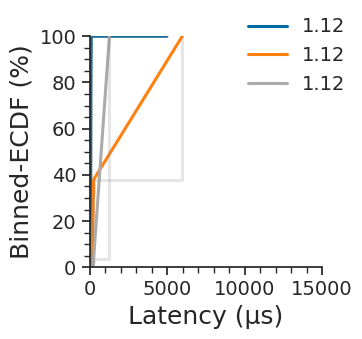

In [46]:
fig, ax1 = plt.subplots(nrows=1, ncols=1, figsize=[3, 3])

mode_sel = "pab"  # <-- pick your Mode here

t_df = combined_df.copy()
t_df = t_df[t_df["IPv4 :Raw priority"] == "0x0"]
t_df = t_df[t_df["Mode"] == mode_sel]
t_df = t_df[t_df["Repeat"] == 5]
t_df = t_df[t_df["Case"] == 'balanced']
# t_df = t_df[t_df["N TC"] != 8]
t_df = t_df[t_df["Overload"] == 1.12]

maximums_nusers = {
    (1.5, 2,): 5000,
    (1.12, 2,): 5000,
    (1.5, 4,): 6000,
    (1.12, 4,): 6000,
    (1.5, 8,): 5000,
    (1.12, 8,): 1300,

    }
groups = group_and_clean(t_df, maximums_nusers, ["Overload", "N TC"])

# ax1.set_xscale('logit')
#ax1.set_prop_cycle(cycler(color=okabe_ito))

draw_ecdf_plots(
    ax1,
    groups,
    {"column": "IPv4 :Raw priority", "name": "0x0"},
    [0, 15000],
    False,
    None,
    '.',
    True,
    linestyle='--'
)



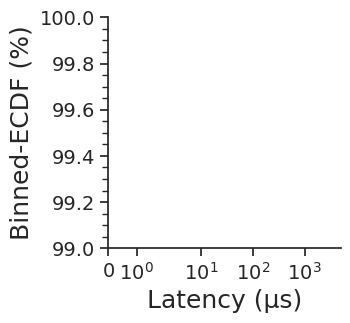

In [552]:
fig, ax1 = plt.subplots(nrows=1, ncols=1, figsize=[3, 3])

mode_sel = "freerunswscheduler"  # <-- pick your Mode here

t_df = combined_df.copy()
t_df = t_df[t_df["IPv4 :Raw priority"] == "0x0"]
t_df = t_df[t_df["Mode"] == mode_sel]
t_df = t_df[t_df["Repeat"] == 30]
# t_df = t_df[t_df["N TC"] != 8]
t_df = t_df[t_df["Overload"] == 1.12]

maximums_nusers = {
    (1.5, 2,): 5000,
    (1.12, 2,): 5000,
    (1.5, 4,): 6000,
    (1.12, 4,): 6000,
    (1.5, 8,): 5000,
    (1.12, 8,): 5000,

    }
groups = group_and_clean(t_df, maximums_nusers, ["Overload", "N TC"])

# ax1.set_xscale('logit')
ax1.set_prop_cycle(cycler(color=okabe_ito))

draw_ecdf_plots(
    ax1,
    groups,
    {"column": "IPv4 :Raw priority", "name": "0x0"},
    [0, 4000],
    False,
    None,
    '.',
    True,
    linestyle='--'
)


mode_sel = "pab"  # <-- pick your Mode here

t_df = combined_df.copy()
t_df = t_df[t_df["IPv4 :Raw priority"] == "0x0"]
t_df = t_df[t_df["Mode"] == mode_sel]
t_df = t_df[t_df["Repeat"] == 30]
t_df = t_df[t_df["N TC"] != 8]
t_df = t_df[t_df["Overload"] == 1.5]

maximums_nusers = {
    (1.5, 2,): 300,
    (1.12, 2,): 300,
    (1.5, 4,): 550,
    (1.12, 4,): 550,
    (1.5, 8,): 550,
    (1.12, 8,): 550,
    }
groups = group_and_clean(t_df, maximums_nusers, ["Overload", "N TC"])

# ax1.set_xscale('logit')
ax1.set_prop_cycle(cycler(color=okabe_ito))

draw_ecdf_plots(
    ax1,
    groups,
    {"column": "IPv4 :Raw priority", "name": "0x0"},
    [0, 5000],
    False,
    None,
    '.',
    True,
)
ax1.set_ylim(99,100)

ax1.set_xscale("symlog")


# fig.savefig('/home/rubinhus/Documents/phd/thesis/backpressure/plots/PAB_ECDF_flows.pdf', bbox_inches="tight")

50%= 80.74522883870381 99%= 139.92294633943703
50%= 160.54609090596855 99%= 279.6805354399888
50%= 84.67236810780625 99%= 146.68806077801173
50%= 169.86748146225494 99%= 301.75536050198133


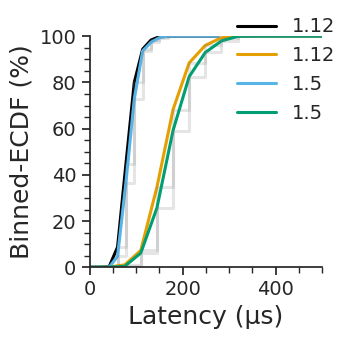

In [211]:
fig, ax1 = plt.subplots(nrows=1, ncols=1, figsize=[3, 3])

mode_sel = "pab"  # <-- pick your Mode here

t_df = combined_df.copy()
t_df = t_df[t_df["IPv4 :Raw priority"] == "0x0"]
t_df = t_df[t_df["Mode"] == mode_sel]
t_df = t_df[t_df["Repeat"] == 30]
t_df = t_df[t_df["N TC"] != 8]

maximums_nusers = {
    (1.5, 2,): 300,
    (1.12, 2,): 300,
    (1.5, 4,): 550,
    (1.12, 4,): 550,
    (1.5, 8,): 550,
    (1.12, 8,): 550,

    }
groups = group_and_clean(t_df, maximums_nusers, ["Overload", "N TC"])

# ax1.set_xscale('logit')
ax1.set_prop_cycle(cycler(color=okabe_ito))

draw_ecdf_plots(
    ax1,
    groups,
    {"column": "IPv4 :Raw priority", "name": "0x0"},
    [0, 500],
    False,
    None,
    '.',
    True,
)


# fig.savefig('/home/rubinhus/Documents/phd/thesis/backpressure/plots/PAB_ECDF_flows.pdf', bbox_inches="tight")

In [161]:
combined_df.groupby(
    ['Instance', 'Mode', 'Overload', 'Flow Group']
)['Tx Frame Rate'].describe()

count  \
Instance Mode Overload Flow Group                                             
1        pab  1.12     HQoS Traffic-cpu0-flow0-hp - Flow Group 0001    15.0   
                       HQoS Traffic-cpu0-flow0-lp - Flow Group 0001     5.0   
                       HQoS Traffic-cpu0-flow0-lp1 - Flow Group 0001   10.0   
                       HQoS Traffic-cpu0-flow0-lp2 - Flow Group 0001   10.0   
                       HQoS Traffic-cpu0-flow0-lp3 - Flow Group 0001   10.0   
                       HQoS Traffic-cpu0-flow0-lp4 - Flow Group 0001    5.0   
                       HQoS Traffic-cpu0-flow0-lp5 - Flow Group 0001    5.0   
                       HQoS Traffic-cpu0-flow0-lp6 - Flow Group 0001    5.0   
                       HQoS Traffic-cpu0-flow0-lp7 - Flow Group 0001    5.0   
              1.50     HQoS Traffic-cpu0-flow0-hp - Flow Group 0001    15.0   
                       HQoS Traffic-cpu0-flow0-lp - Flow Group 0001     5.0   
                       HQoS Traffic-cpu0-flow0-lp1 - Flow Group 0001   10.0   
                       HQoS Traffic-cpu0-flow0-lp2 - Flow Group 0001   10.0   
                       HQoS Traffic-cpu0-flow0-lp3 - Flow Group 0001   10.0   
                       HQoS Traffic-cpu0-flow0-lp4 - Flow Group 0001    5.0   
                       HQoS Traffic-cpu0-flow0-lp5 - Flow Group 0001    5.0   
                       HQoS Traffic-cpu0-flow0-lp6 - Flow Group 0001    5.0   
                       HQoS Traffic-cpu0-flow0-lp7 - Flow Group 0001    5.0   

                                                                              mean  \
Instance Mode Overload Flow Group                                                    
1        pab  1.12     HQoS Traffic-cpu0-flow0-hp - Flow Group 0001   1.649988e+06   
                       HQoS Traffic-cpu0-flow0-lp - Flow Group 0001   1.404494e+06   
                       HQoS Traffic-cpu0-flow0-lp1 - Flow Group 0001  5.097560e+05   
                       HQoS Traffic-cpu0-flow0-lp2 - Flow Group 0001  5.097559e+05   
                       HQoS Traffic-cpu0-flow0-lp3 - Flow Group 0001  5.097560e+05   
                       HQoS Traffic-cpu0-flow0-lp4 - Flow Group 0001  3.058535e+05   
                       HQoS Traffic-cpu0-flow0-lp5 - Flow Group 0001  3.058535e+05   
                       HQoS Traffic-cpu0-flow0-lp6 - Flow Group 0001  3.058537e+05   
                       HQoS Traffic-cpu0-flow0-lp7 - Flow Group 0001  3.058539e+05   
              1.50     HQoS Traffic-cpu0-flow0-hp - Flow Group 0001   1.876404e+06   
                       HQoS Traffic-cpu0-flow0-lp - Flow Group 0001   1.404494e+06   
                       HQoS Traffic-cpu0-flow0-lp1 - Flow Group 0001  6.806956e+05   
                       HQoS Traffic-cpu0-flow0-lp2 - Flow Group 0001  6.806957e+05   
                       HQoS Traffic-cpu0-flow0-lp3 - Flow Group 0001  6.806956e+05   
                       HQoS Traffic-cpu0-flow0-lp4 - Flow Group 0001  3.869732e+05   
                       HQoS Traffic-cpu0-flow0-lp5 - Flow Group 0001  3.869732e+05   
                       HQoS Traffic-cpu0-flow0-lp6 - Flow Group 0001  3.869731e+05   
                       HQoS Traffic-cpu0-flow0-lp7 - Flow Group 0001  3.869731e+05   

                                                                                std  \
Instance Mode Overload Flow Group                                                     
1        pab  1.12     HQoS Traffic-cpu0-flow0-hp - Flow Group 0001   359365.686838   
                       HQoS Traffic-cpu0-flow0-lp - Flow Group 0001        0.273861   
                       HQoS Traffic-cpu0-flow0-lp1 - Flow Group 0001  214932.054163   
                       HQoS Traffic-cpu0-flow0-lp2 - Flow Group 0001  214932.001458   
                       HQoS Traffic-cpu0-flow0-lp3 - Flow Group 0001  214932.054163   
                       HQoS Traffic-cpu0-flow0-lp4 - Flow Group 0001       0.000000   
                       HQoS Traffic-cpu0-flow0-lp5 - Flow Group 0001    

In [439]:
base_dir = "/home/rubinhus/Documents/phd/thesis/backpressure/data/single_user_unfairness/"
pattern = "**/*Latency_Bins cross page.csv"

all_dfs = []

csv_files = glob.glob(os.path.join(base_dir, pattern), recursive=True)

for path in csv_files:
   
    # Split folder name into components safely
    folder = path.split("/")
    # print(folder)
    if 'old' in path:
        continue
    try:
        ninstances = int(folder[-5].split("_")[0].strip('instances'))
        experiment = folder[-5].split("_")[1]
        overload = float(folder[-4].split("_")[0])
        repeat = int(folder[-4].split("_")[1].strip('x'))

        # overload = float(parts[-4].strip("_"))
        # print(overload)
                          
        df = pd.read_csv(path)
        df["Instance"] = ninstances
        df["Overload"] = overload
        df["Experiment"] = experiment
        df["Repeat"] = repeat
        all_dfs.append(df)
    except Exception as e:
        print(f"Failed to parse {folder_name}: {e}")

# Combine all datasets
combined_df = pd.concat(all_dfs, ignore_index=True)

# Optional: sort or save
# combined_df = combined_df.sort_values(by="source")
# combined_df.to_csv("/home/rubinhus/combined_aggregateresults.csv", index=False)

print(f"Loaded {len(combined_df)} rows from {len(all_dfs)} files")

Loaded 60 rows from 15 files


In [440]:
set(combined_df['Experiment'])

{'default', 'pab', 'prioprop'}

In [441]:
combined_df.columns

Index(['Rx Port', 'IPv4 :Raw priority', 'Flow Group', 'Tx Frames', 'Rx Frames',
       'Rx Frames per Bin : 0us - 800us',
       'Rx Frames per Bin : 800us - 1013.34us',
       'Rx Frames per Bin : 1013.34us - 1226.66us',
       'Rx Frames per Bin : 1226.66us - 1440us',
       'Rx Frames per Bin : 1440us - 1653.34us',
       'Rx Frames per Bin : 1653.34us - 1866.66us',
       'Rx Frames per Bin : 1866.66us - 2080us',
       'Rx Frames per Bin : 2080us - 2293.34us',
       'Rx Frames per Bin : 2293.34us - 2506.66us',
       'Rx Frames per Bin : 2506.66us - 2720us',
       'Rx Frames per Bin : 2720us - 2933.34us',
       'Rx Frames per Bin : 2933.34us - 3146.66us',
       'Rx Frames per Bin : 3146.66us - 3360us',
       'Rx Frames per Bin : 3360us - 3573.34us',
       'Rx Frames per Bin : 3573.34us - 3786.66us',
       'Rx Frames per Bin : 3786.66us - maxus', 'Loss %', 'Tx Frame Rate',
       'Rx Frame Rate', 'Tx Rate (bps)', 'Rx Rate (bps)',
       'Cut-Through Avg Latency (ns)', 'Cut-T

In [ ]:
default                    0.500032                    10.027189                  24.06
pab                        0.500127                     9.903805                  23.64
prioprop                   0.987628                    11.657266                  25.20


In [313]:
(11.657266/25.20)*100

46.258992063492066

In [312]:
(9.903805/23.64)*100

41.894268189509305

In [311]:
(10.027189/24.06)*100

41.67576475477972

In [444]:
# Extract lp number (lp1, lp2, ...)
df['prio'] = df['Flow Group'].str.extract(r'(lp\d)')
df['prio']

0    lp4
1    lp3
2    lp2
3    lp1
Name: prio, dtype: object

In [448]:
df

,Experiment,Flow Group,Loss %,prio
0,default,HQoS Traffic-cpu0-flow0-lp1 - Flow Group 0001,53.4616,G1
1,default,HQoS Traffic-cpu0-flow0-lp2 - Flow Group 0001,18.5250,G2
2,default,HQoS Traffic-cpu0-flow0-lp3 - Flow Group 0001,0.0014,G3
3,default,HQoS Traffic-cpu0-flow0-lp4 - Flow Group 0001,52.4766,G4
4,pab,HQoS Traffic-cpu0-flow0-lp1 - Flow Group 0001,50.6048,G1
5,pab,HQoS Traffic-cpu0-flow0-lp2 - Flow Group 0001,18.3200,G2
6,pab,HQoS Traffic-cpu0-flow0-lp3 - Flow Group 0001,0.0050,G3
7,pab,HQoS Traffic-cpu0-flow0-lp4 - Flow Group 0001,50.6078,G4
8,prioprop,HQoS Traffic-cpu0-flow0-lp1 - Flow Group 0001,31.3080,G1
9,prioprop,HQoS Traffic-cpu0-flow0-lp2 - Flow Group 0001,31.3592,G2


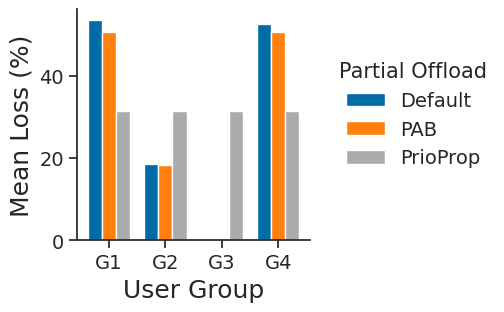

In [447]:
df = combined_df.groupby(
    ['Experiment', 'Flow Group']
)[['Loss %']].mean().reset_index()

# Extract lp number (lp1, lp2, ...)
df['prio'] = df['Flow Group'].str.extract(r'(lp\d)')
df['prio'] = df['prio'].str.replace('lp', 'G', regex=False)

experiments = df['Experiment'].unique()
prios = sorted(df['prio'].unique())

x = range(len(prios))
bar_width = 0.25

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=[3, 3])

for i, exp in enumerate(experiments):
    exp_df = df[df['Experiment'] == exp]
    plt.bar(
        [p + i * bar_width for p in x],
        exp_df.set_index('prio').loc[prios]['Loss %'],
        width=bar_width,
        label=exp
    )

plt.xticks(
    [p + bar_width for p in x],
    prios
)
plt.xlabel('User Group')
plt.ylabel('Mean Loss (%)')
# plt.title('Mean Packet Loss per Priority and Experiment')
plt.legend(title='Partial Offload', frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(
    labels=["Default", "PAB", "PrioProp"],
    loc="upper left",    
    bbox_to_anchor=(1.05, 0.85),
    frameon=False,
    title="Partial Offload"
)# leg.set_title(title="N Instances")

plt.tight_layout()
plt.show()

# fig.savefig('/home/rubinhus/Documents/phd/thesis/backpressure/plots/unfairness.pdf', bbox_inches="tight")

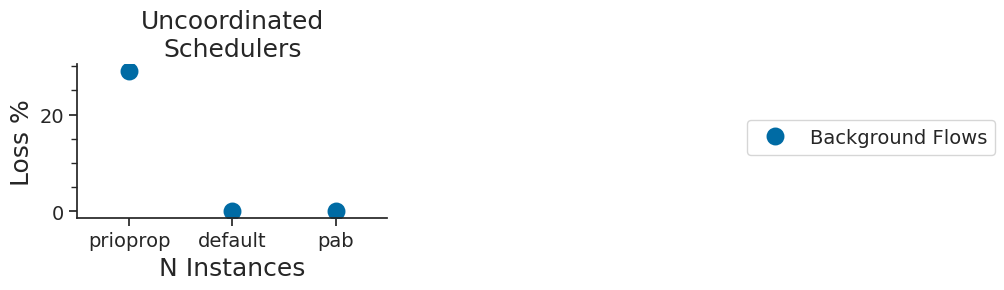

In [365]:
fig, ax1 = plt.subplots(1, 1, figsize=(4, 2), sharey=True, sharex=True)


sns.pointplot(
    data=p_df,
    x="Experiment",
    y="Loss %",
    label="Background Flows",
    ax=ax1,
    join=False,
)

legend1 = ax1.legend(
    loc="upper left",
    bbox_to_anchor=(2.13, 0.7),
)

# ax1.xaxis.set_major_locator(plt.AutoLocator())
# ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax1.yaxis.set_major_locator(plt.AutoLocator())
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())

#fig.suptitle(
#    "Single TC Flow Loss, Overload x = 1.5\n4000 Flows and Multiple Instances", y=1.4
#)

ax1.set_title("Uncoordinated\nSchedulers")
ax2.set_title("Priority\nPropagation")
ax1.set_xlabel("N Instances")
ax2.set_xlabel("N Instances")

sns.despine()

# fig.savefig('/home/rubinhus/Documents/phd/thesis/backpressure/plots/single_user_unfairness.pdf', bbox_inches="tight")

In [318]:
combined_df.columns

Index(['Rx Port', 'IPv4 :Raw priority', 'Flow Group', 'Tx Frames', 'Rx Frames',
       'Rx Frames per Bin : 0us - 30us', 'Rx Frames per Bin : 30us - 33.34us',
       'Rx Frames per Bin : 33.34us - 36.66us',
       'Rx Frames per Bin : 36.66us - 40us',
       'Rx Frames per Bin : 40us - 43.34us',
       'Rx Frames per Bin : 43.34us - 46.66us',
       'Rx Frames per Bin : 46.66us - 50us',
       'Rx Frames per Bin : 50us - 53.34us',
       'Rx Frames per Bin : 53.34us - 56.66us',
       'Rx Frames per Bin : 56.66us - 60us',
       'Rx Frames per Bin : 60us - 63.34us',
       'Rx Frames per Bin : 63.34us - 66.66us',
       'Rx Frames per Bin : 66.66us - 70us',
       'Rx Frames per Bin : 70us - 73.34us',
       'Rx Frames per Bin : 73.34us - 76.66us',
       'Rx Frames per Bin : 76.66us - maxus', 'Loss %', 'Tx Frame Rate',
       'Rx Frame Rate', 'Tx Rate (bps)', 'Rx Rate (bps)',
       'Cut-Through Avg Latency (ns)', 'Cut-Through Min Latency (ns)',
       'Cut-Through Max Latency (ns)', 

In [316]:
import pandas as pd

# Filter target flow and background flows
target_flow = 'HQoS Traffic-cpu0-flow0-hp - Flow Group 0001'

# Separate the experiments
experiments = ['default', 'prioprop']

# Initialize a list to collect table rows
table_rows = []

for exp in experiments:
    # Target flow
    p_df = combined_df[
        (combined_df['Flow Group'] == target_flow) & 
        (combined_df['Experiment'] == exp)
    ]
    for _, row in p_df.iterrows():
        table_rows.append({
            'Experiment': exp,
            'Flow Type': 'Target Flow',
            'Instance': row['Instance'],
            'Loss %': row['Loss %']
        })
    
    # Background flows
    p_df_bg = combined_df[
        (combined_df['Flow Group'] != target_flow) & 
        (combined_df['Experiment'] == exp)
    ]
    for _, row in p_df_bg.iterrows():
        table_rows.append({
            'Experiment': exp,
            'Flow Type': 'Background Flows',
            'Instance': row['Instance'],
            'Loss %': row['Loss %']
        })

# Convert to DataFrame
loss_table = pd.DataFrame(table_rows)

# Optionally, pivot to make it more readable (Instances as rows, Flow Types & Experiments as columns)
loss_table_pivot = loss_table.pivot_table(
    index='Instance',
    columns=['Experiment', 'Flow Type'],
    values='Loss %'
)

# Reset index for nicer display
loss_table_pivot.reset_index(inplace=True)

print(loss_table_pivot)


Experiment Instance          default                     prioprop            
Flow Type           Background Flows Target Flow Background Flows Target Flow
0                 1        38.212200      0.0000         39.23560      0.0000
1                 2        32.813000     30.8028         32.63500     33.8164
2                 4        32.813000     32.3062         32.81300     32.9074
3                 8        32.813125     33.3630         32.81305     39.7505


In [ ]:
import pandas as pd

# Define the target flow
target_flow = 'HQoS Traffic-cpu0-flow0-hp - Flow Group 0001'
experiments = ['default', 'prioprop']

# Collect rows
table_rows = []

for exp in experiments:
    # Target flow
    p_df = combined_df[
        (combined_df['Flow Group'] == target_flow) &
        (combined_df['Experiment'] == exp)
    ]
    for _, row in p_df.iterrows():
        table_rows.append({
            'Experiment': exp,
            'Flow Type': 'Target Flow',
            'Instance': row['Instance'],
            'Loss %': row['Loss %']
        })
    
    # Background flows
    p_df_bg = combined_df[
        (combined_df['Flow Group'] != target_flow) &
        (combined_df['Experiment'] == exp)
    ]
    for _, row in p_df_bg.iterrows():
        table_rows.append({
            'Experiment': exp,
            'Flow Type': 'Background Flows',
            'Instance': row['Instance'],
            'Loss %': row['Loss %']
        })

# Create DataFrame
loss_table = pd.DataFrame(table_rows)

# Pivot for better readability (Instances as rows, Experiments+Flow as columns)
loss_table_pivot = loss_table.pivot_table(
    index='Instance',
    columns=['Experiment', 'Flow Type'],
    values='Loss %'
).reset_index()

# Compute aggregate statistics
agg_stats = loss_table.groupby(['Experiment', 'Flow Type']).agg(
    Mean_Loss=('Loss %', 'mean'),
    Min_Loss=('Loss %', 'min'),
    Max_Loss=('Loss %', 'max')
).reset_index()

print(loss_table_pivot)

In [ ]:
combined_df.columns

In [ ]:
p_df = combined_df[combined_df['Experiment'] == 'prioprop']
target_flow = 'HQoS Traffic-cpu0-flow0-hp - Flow Group 0001'
p_df = p_df[p_df['Flow Group'] == target_flow]
p_df.groupby(['Instance'])['Cut-Through Min Latency (ns)'].describe()

In [ ]:
p_df.groupby(['Instance'])[['Cut-Through Avg Latency (ns)','Cut-Through Max Latency (ns)']].mean()/1E3

In [ ]:
256000000/2